In [5]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 18
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.minor.size'] = 3
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.figsize'] = (7,3.5)

In [ ]:
"""
CSMF HOD Fitter using Nautilus Sampler and iminuit Minimization
================================================================

This module provides a class for fitting the Conditional Stellar Mass Function
(CSMF) HOD model to galaxy-galaxy lensing measurements (Delta Sigma) and
optionally galaxy clustering (WGG) using:
- Nautilus nested sampling algorithm (for full posterior)
- iminuit minimization (for fast best-fit finding)

Features:
- Support for fitting multiple stellar mass bins simultaneously
- Each mass bin has its own stellar mass range and effective redshift
- Uses the multi-redshift CSMF halo model functionality
- Flexible prior specification (uniform, Gaussian, fixed)
- Choice of observables to fit (DeltaSigma, WGG, or both)
- Support for different rp bins for WGG and DeltaSigma
- Efficient model evaluation using pre-computed halo model quantities
- Fast best-fit finding with iminuit (MIGRAD, HESSE, MINOS)

Author: CSMF Fitting Pipeline
Modified: December 2025 - Updated for new HaloModel class API
"""

import numpy as np
from typing import Dict, List, Optional, Union, Tuple, Any, Callable
from dataclasses import dataclass, field
from scipy.stats import norm
import pyccl as ccl
import warnings
import os


# # Import from the new halo_model module
# from HOD_NRV.HOD_analytical.halo_model import ( HODType, CSMF_HOD,
#     create_hod, CSMF_HOD_PARAMS
# )


# Try to import nautilus
try:
    from nautilus import Prior, Sampler
    HAS_NAUTILUS = True
except ImportError:
    HAS_NAUTILUS = False
    warnings.warn("nautilus-sampler not installed. Install with: pip install nautilus-sampler")

# Try to import iminuit
try:
    from iminuit import Minuit
    from iminuit.util import describe
    HAS_IMINUIT = True
except ImportError:
    HAS_IMINUIT = False
    warnings.warn("iminuit not installed. Install with: pip install iminuit")

# scipy is always available
from scipy.optimize import differential_evolution, minimize as scipy_minimize
from scipy.optimize import OptimizeResult


# ============================================================================
# Default Cosmology (from null_test.py)
# ============================================================================

DEFAULT_COSMO_PARAMS = {
    'h': 0.6766,
    'Omc': 0.11933 / (0.6766)**2,
    'Omb': 0.02242 / (0.6766)**2,
    's8': 0.8102,
    'A_s': 2.105209331337507e-09,
    'n_s': 0.9665,
    'Omnu': 0.0014034
}


# ============================================================================
# Prior Configuration
# ============================================================================

@dataclass
class ParameterPrior:
    """
    Configuration for a single parameter prior.
    
    Attributes
    ----------
    name : str
        Parameter name
    prior_type : str
        Type of prior: 'uniform', 'gaussian', or 'fixed'
    bounds : tuple, optional
        (min, max) for uniform priors
    mean : float, optional
        Mean for Gaussian priors
    std : float, optional
        Standard deviation for Gaussian priors
    fixed_value : float, optional
        Value for fixed parameters
    """
    name: str
    prior_type: str = 'uniform'
    bounds: Optional[Tuple[float, float]] = None
    mean: Optional[float] = None
    std: Optional[float] = None
    fixed_value: Optional[float] = None
    
    def __post_init__(self):
        """Validate the prior configuration"""
        if self.prior_type == 'uniform':
            if self.bounds is None:
                raise ValueError(f"Parameter {self.name}: uniform prior requires bounds")
        elif self.prior_type == 'gaussian':
            if self.mean is None or self.std is None:
                raise ValueError(f"Parameter {self.name}: Gaussian prior requires mean and std")
        elif self.prior_type == 'fixed':
            if self.fixed_value is None:
                raise ValueError(f"Parameter {self.name}: fixed prior requires fixed_value")
        else:
            raise ValueError(f"Unknown prior type: {self.prior_type}")


DEFAULT_CSMF_PRIORS = {
    # Characteristic stellar mass log10(M*/[Msun/h²])
    # Table shows log(L0/[h^-2 L_sun]) with prior [7, 13]
    # Converting to stellar mass: roughly [9.0, 14.0] in log10(Msun/h²)
    'M0': ParameterPrior(
        name='M0',
        prior_type='uniform',
        bounds=(8.0, 13.0)
    ),
    
    # Characteristic halo mass log10(Mh/[Msun/h])
    # Table shows [9.0, 14.0]
    'M1': ParameterPrior(
        name='M1',
        prior_type='uniform',
        bounds=(9.0, 14.0)
    ),
    
    # Low-mass slope of SHMR
    'gamma1': ParameterPrior(
        name='gamma1',
        prior_type='uniform',
        bounds=(2.0, 15.0)
    ),
    
    # High-mass slope of SHMR
    # Table shows [0, 2]
    'gamma2': ParameterPrior(
        name='gamma2',
        prior_type='uniform',
        bounds=(0.0, 5.0)
    ),
    
    # Scatter in central stellar mass
    # Table shows [0.1, 0.3]
    'sigma_c': ParameterPrior(
        name='sigma_c',
        prior_type='uniform',
        bounds=(0.05, 1.2)
    ),
    
    # Satellite Schechter function slope
    # Table shows N(-1.1, 0.9)
    'alpha_s': ParameterPrior(
        name='alpha_s',
        prior_type='uniform',
        bounds=(-5, 5)
    ),
    
    # Satellite normalization intercept
    # Table shows N(0, 1.5)
    'b0': ParameterPrior(
        name='b0',
        prior_type='uniform',
        bounds=(-5, 5)
    ),

    # Satellite normalization slope
    'b1': ParameterPrior(
        name='b1',
        prior_type='uniform',
        bounds=(-5, 5)
    ),
    
    # Central concentration parameter (Fc in table)
    # Table shows [0.1, 1] - this is f_conc
    'f_c': ParameterPrior(
        name='f_c',
        prior_type='uniform',
        bounds=(0.2, 1.0)
    ),
    
    # Satellite concentration parameter (Fs)
    # Can be fixed to 1 or varied
    'f_s': ParameterPrior(
        name='f_s',
        prior_type='uniform',
        bounds=(0.2, 1.0)
    ),
}

FIDUCIAL_CSMF_PARAMS = {
    'M0': 10.5,
    'M1': 12.0,
    'gamma1': 7.0,
    'gamma2': 0.2,
    'sigma_c': 0.2,
    'alpha_s': -1.0,
    'b0': -2.0,
    'b1': 1.0,
    'f_c': 0.7,
    'f_s': 0.7
}


@dataclass
class MassBinData:
    """
    Container for a single stellar mass bin's data.
    """
    massbin_id: int
    z_eff: float
    logmstar_min: float
    logmstar_max: float
    logmstar_median: Optional[float] = None
    rp: np.ndarray = field(default_factory=lambda: np.array([]))
    rp_bins: np.ndarray = field(default_factory=lambda: np.array([]))
    delta_sigma: np.ndarray = field(default_factory=lambda: np.array([]))
    delta_sigma_err: np.ndarray = field(default_factory=lambda: np.array([]))
    cov_delta_sigma: np.ndarray = field(default_factory=lambda: np.array([]))
    rp_wgg: Optional[np.ndarray] = None
    rp_bins_wgg: Optional[np.ndarray] = None
    wp: Optional[np.ndarray] = None
    wp_err: Optional[np.ndarray] = None
    cov_wgg: Optional[np.ndarray] = None
    mag_contribution: Optional[np.ndarray] = None
    mean_sigma_crit: Optional[np.ndarray] = None
    
    def __post_init__(self):
        if self.rp_wgg is None:
            self.rp_wgg = self.rp.copy()
        if self.rp_bins_wgg is None:
            self.rp_bins_wgg = self.rp_bins.copy()
    
    @classmethod
    def from_npz(cls, filepath: str, massbin_id: int, h: float) -> 'MassBinData':
        data = np.load(filepath)

        if 'rp_delta_sigma' in data:
            rp = data['rp_delta_sigma']
        elif 'rp' in data:
            rp = data['rp']
        else:
            raise KeyError("Could not find 'rp' or 'rp_delta_sigma' in data file")

        rp_wgg = data.get('rp_wgg', rp)
        rp_bins_wgg = data.get('rp_bins_wgg', data['rp_bins'])

        if 'cov_delta_sigma' in data:
            cov_delta_sigma = data['cov_delta_sigma']
        elif 'covariance_matrix' in data:
            cov_delta_sigma = data['covariance_matrix']
        else:
            raise KeyError("Could not find covariance matrix in data file")

        return cls(
            massbin_id=massbin_id,
            z_eff=float(data['z_eff']),
            logmstar_min=float(data['logmstar_min']), #- 2*np.log10(DEFAULT_COSMO_PARAMS['h']),
            logmstar_max=float(data['logmstar_max']), #- 2*np.log10(DEFAULT_COSMO_PARAMS['h']),
            logmstar_median=float(data['logmstar_median']), #- 2*np.log10(DEFAULT_COSMO_PARAMS['h']),
            rp=rp,
            rp_bins=data['rp_bins'],
            delta_sigma=data['delta_sigma'],
            delta_sigma_err=data['delta_sigma_err'],
            cov_delta_sigma=cov_delta_sigma,
            rp_wgg=rp_wgg,
            rp_bins_wgg=rp_bins_wgg,
            wp=data.get('wp', None),
            wp_err=data.get('wp_err', None),
            cov_wgg=data.get('cov_wgg', None),
            mag_contribution=data.get('mag_contribution', None),
            mean_sigma_crit=data.get('mean_sigma_crit', None),
        )


# ============================================================================
# Minuit Result Container
# ============================================================================

@dataclass
class MinuitResult:
    """
    Container for iminuit minimization results.
    """
    best_fit: Dict[str, float]
    errors: Dict[str, float]
    minos_errors: Optional[Dict[str, Tuple[float, float]]]
    covariance: np.ndarray
    correlation: np.ndarray
    chi2: float
    ndof: int
    reduced_chi2: float
    fval: float
    is_valid: bool
    has_accurate_covar: bool
    param_names: List[str]
    minuit: Any
    
    def print_summary(self):
        """Print a summary of the fit results."""
        print("\n" + "="*70)
        print("MINUIT FIT RESULTS")
        print("="*70)
        
        print(f"\nFit status: {'CONVERGED' if self.is_valid else 'FAILED'}")
        print(f"Covariance: {'ACCURATE' if self.has_accurate_covar else 'APPROXIMATE'}")
        print(f"\nχ² = {self.chi2:.2f}")
        print(f"ndof = {self.ndof}")
        print(f"χ²/ndof = {self.reduced_chi2:.3f}")
        
        print(f"\nBest-fit parameters:")
        print("-"*50)
        
        for name in self.param_names:
            val = self.best_fit[name]
            err = self.errors.get(name, 0)
            
            if self.minos_errors and name in self.minos_errors:
                err_lo, err_hi = self.minos_errors[name]
                print(f"  {name:12s} = {val:12.5f}  +{err_hi:.5f}  {err_lo:.5f}")
            else:
                print(f"  {name:12s} = {val:12.5f} ± {err:.5f}")
        
        fixed_params = {k: v for k, v in self.best_fit.items() if k not in self.param_names}
        if fixed_params:
            print(f"\nFixed parameters:")
            print("-"*50)
            for name, val in fixed_params.items():
                print(f"  {name:12s} = {val:12.5f} (FIXED)")
        
        print("="*70)


@dataclass
class DifferentialEvolutionResult:
    """
    Container for scipy differential evolution results.
    """
    best_fit: Dict[str, float]
    chi2: float
    ndof: int
    reduced_chi2: float
    success: bool
    message: str
    n_iterations: int
    n_function_evals: int
    param_names: List[str]
    scipy_result: Any
    errors: Optional[Dict[str, float]] = None
    covariance: Optional[np.ndarray] = None
    
    def print_summary(self):
        """Print a summary of the fit results."""
        print("\n" + "="*70)
        print("DIFFERENTIAL EVOLUTION FIT RESULTS")
        print("="*70)
        
        print(f"\nFit status: {'CONVERGED' if self.success else 'FAILED'}")
        print(f"Message: {self.message}")
        print(f"Iterations: {self.n_iterations}")
        print(f"Function evaluations: {self.n_function_evals}")
        print(f"\nχ² = {self.chi2:.2f}")
        print(f"ndof = {self.ndof}")
        print(f"χ²/ndof = {self.reduced_chi2:.3f}")
        
        print(f"\nBest-fit parameters:")
        print("-"*50)
        
        for name in self.param_names:
            val = self.best_fit[name]
            if self.errors and name in self.errors:
                err = self.errors[name]
                print(f"  {name:12s} = {val:12.5f} ± {err:.5f}")
            else:
                print(f"  {name:12s} = {val:12.5f}")
        
        fixed_params = {k: v for k, v in self.best_fit.items() if k not in self.param_names}
        if fixed_params:
            print(f"\nFixed parameters:")
            print("-"*50)
            for name, val in fixed_params.items():
                print(f"  {name:12s} = {val:12.5f} (FIXED)")
        
        print("="*70)


# ============================================================================
# Main CSMF Fitter Class
# ============================================================================

class CSMFFitter:
    """
    CSMF HOD Fitter using Nautilus nested sampling and iminuit minimization.
    
    This class handles fitting the CSMF HOD model to galaxy-galaxy lensing
    (Delta Sigma) and optionally galaxy clustering (w_p) measurements.
    
    Parameters
    ----------
    cosmo_params : dict, optional
        Cosmology parameters. Default uses the fiducial cosmology.
    observables : list of str
        Which observables to fit. Options: ['DeltaSigma', 'WGG']
    rp_min : float, optional
        Minimum r_p to include in fit [Mpc/h]
    rp_max : float, optional
        Maximum r_p to include in fit [Mpc/h]
    rp_min_wgg : float, optional
        Minimum r_p for WGG fit [Mpc/h]
    rp_max_wgg : float, optional
        Maximum r_p for WGG fit [Mpc/h]
    units_per_h : bool
        Whether to use h-units. Default: True
    verbose : bool
        Print progress information. Default: True
    """
    
    def __init__(
        self,
        cosmo_params: Optional[Dict] = None,
        observables: List[str] = None,
        rp_min: Optional[float] = None,
        rp_max: Optional[float] = None,
        rp_min_wgg: Optional[float] = None,
        rp_max_wgg: Optional[float] = None,
        units_per_h: bool = True,
        verbose: bool = True
    ):
        self.observables = observables or ['DeltaSigma']
        self.rp_min = rp_min
        self.rp_max = rp_max
        self.rp_min_wgg = rp_min_wgg if rp_min_wgg is not None else rp_min
        self.rp_max_wgg = rp_max_wgg if rp_max_wgg is not None else rp_max
        self.units_per_h = units_per_h
        self.verbose = verbose
        
        if cosmo_params is None:
            cosmo_params = DEFAULT_COSMO_PARAMS
        self.cosmo_params = cosmo_params
        self._setup_cosmology()
        
        self.mass_bins: List[MassBinData] = []
        self.priors: Dict[str, ParameterPrior] = {}
        self.fixed_params: Dict[str, float] = {}
        
        self._halo_model: Optional[HaloModel] = None
        self._z_eff_array: Optional[np.ndarray] = None
        self._mstar_min_array: Optional[np.ndarray] = None
        self._mstar_max_array: Optional[np.ndarray] = None
        self._massbin_id_to_index: Optional[Dict[int, int]] = None
        self._median_mstar_array: Optional[np.ndarray] = None
        
        # Results storage
        self.sampler: Optional[Any] = None
        self.results: Optional[Dict] = None
        self.minuit_result: Optional[MinuitResult] = None
        self.de_result: Optional[DifferentialEvolutionResult] = None
        
        # Cache for number of data points (for chi2/ndof calculation)
        self._n_data_points: Optional[int] = None
    
    def _setup_cosmology(self):
        """Initialize CCL cosmology object"""
        Omc = self.cosmo_params['Omc']
        Omb = self.cosmo_params['Omb']
        h = self.cosmo_params['h']
        As = self.cosmo_params['A_s']
        ns = self.cosmo_params['n_s']
        mnu = 0.06
        
        self.cosmo = ccl.Cosmology(
            Omega_c=Omc,
            Omega_b=Omb,
            m_nu=mnu,
            h=h,
            A_s=As,
            n_s=ns,
            transfer_function='boltzmann_camb',
            matter_power_spectrum='camb',
            mass_split='normal',
            extra_parameters={"camb": {"halofit_version": "mead2020"}}
        )
        
        if self.verbose:
            print(f"Cosmology initialized: Ωc={Omc:.4f}, Ωb={Omb:.4f}, h={h}")
    
    def load_data(
        self,
        data_dir: str,
        mass_bins: Optional[List[int]] = None,
        file_pattern: str = 'dsigma_wgg_massbin{}_SFR.npz'
    ):
        """Load Delta Sigma measurements for specified mass bins."""
        if mass_bins is None:
            mass_bins = list(range(8))
        
        self.mass_bins = []

        for mb in mass_bins:
            filepath = os.path.join(data_dir, file_pattern.format(mb))

            if not os.path.exists(filepath):
                warnings.warn(f"File not found: {filepath}")
                continue

            data = MassBinData.from_npz(filepath, mb, self.cosmo_params['h'])
            self.mass_bins.append(data)
            if self.verbose:
                print(f"Loaded mass bin {mb}: z_eff={data.z_eff:.3f}, "
                      f"log(M*)=[{data.logmstar_min:.2f}, {data.logmstar_max:.2f}]")

        self.mass_bins.sort(key=lambda x: x.z_eff)

        if self.verbose:
            print(f"Total: {len(self.mass_bins)} mass bins loaded")
    
    def set_priors(
        self,
        priors: Optional[Dict[str, ParameterPrior]] = None,
        fixed_params: Optional[Dict[str, float]] = None
    ):
        """Set parameter priors."""
        self.priors = DEFAULT_CSMF_PRIORS.copy()
        
        if priors is not None:
            for name, prior in priors.items():
                self.priors[name] = prior
        
        self.fixed_params = {}
        if fixed_params is not None:
            for name, value in fixed_params.items():
                self.fixed_params[name] = value
                self.priors[name] = ParameterPrior(
                    name=name,
                    prior_type='fixed',
                    fixed_value=value
                )
        
        if self.verbose:
            print("\nParameter configuration:")
            for name, prior in self.priors.items():
                if prior.prior_type == 'fixed':
                    print(f"  {name}: FIXED at {prior.fixed_value}")
                elif prior.prior_type == 'uniform':
                    print(f"  {name}: Uniform{prior.bounds}")
                elif prior.prior_type == 'gaussian':
                    print(f"  {name}: N({prior.mean}, {prior.std})")
    
    def _build_nautilus_prior(self) -> 'Prior':
        """Build nautilus Prior object from parameter configuration."""
        if not HAS_NAUTILUS:
            raise ImportError("nautilus-sampler is required")
        
        prior = Prior()
        csmf_param_names = ['M0', 'M1', 'gamma1', 'gamma2', 'sigma_c', 'alpha_s', 'b0', 'b1']
        optional_params = ['f_c', 'f_s']
        
        for name in csmf_param_names + optional_params:
            if name not in self.priors:
                continue
            
            param_prior = self.priors[name]
            
            if param_prior.prior_type == 'fixed':
                continue
            elif param_prior.prior_type == 'uniform':
                prior.add_parameter(name, dist=param_prior.bounds)
            elif param_prior.prior_type == 'gaussian':
                prior.add_parameter(
                    name,
                    dist=norm(loc=param_prior.mean, scale=param_prior.std)
                )
        
        return prior
    
    def _get_free_param_names(self) -> List[str]:
        """Get list of free (non-fixed) parameter names in consistent order."""
        canonical_order = ['M0', 'M1', 'gamma1', 'gamma2', 'sigma_c', 'alpha_s', 'b0', 'b1', 'f_c', 'f_s']
        return [
            name for name in canonical_order
            if name in self.priors and self.priors[name].prior_type != 'fixed'
        ]
    
    def _build_full_params(self, free_params: Dict[str, float]) -> Dict[str, float]:
        """Build full parameter dictionary including fixed params."""
        full_params = {}
        
        for name, prior in self.priors.items():
            if prior.prior_type == 'fixed':
                full_params[name] = prior.fixed_value
        
        full_params.update(free_params)
        return full_params
    
    def _initialize_halo_model(self):
        """Initialize a SINGLE unified halo model for all mass bins."""
        if not self.mass_bins:
            raise ValueError("No data loaded. Call load_data() first.")
        
        self._z_eff_array = np.array([mb.z_eff for mb in self.mass_bins])
        
        if self.verbose:
            print(f"\nInitializing unified halo model...")
            print(f"  Number of mass bins: {len(self.mass_bins)}")
        
        self._mstar_min_array = np.array([10**mb.logmstar_min for mb in self.mass_bins])
        self._mstar_max_array = np.array([10**mb.logmstar_max for mb in self.mass_bins])

        median_mstar_list = []
        for mb in self.mass_bins:
            if mb.logmstar_median is not None:
                median_mstar_list.append(10**mb.logmstar_median)
            else:
                median_mstar_list.append(None)

        if all(m is None for m in median_mstar_list):
            self._median_mstar_array = None
        elif any(m is None for m in median_mstar_list):
            raise ValueError(
                "Mixed stellar mass bins: all bins must either have or not have median stellar masses."
            )
        else:
            self._median_mstar_array = np.array(median_mstar_list)

        self._massbin_id_to_index = {
            mb.massbin_id: i for i, mb in enumerate(self.mass_bins)
        }
        
        # Initial HOD parameters for model creation
        init_params = {
            'M0': FIDUCIAL_CSMF_PARAMS['M0'],
            'M1': FIDUCIAL_CSMF_PARAMS['M1'],
            'gamma1': FIDUCIAL_CSMF_PARAMS['gamma1'],
            'gamma2': FIDUCIAL_CSMF_PARAMS['gamma2'],
            'sigma_c': FIDUCIAL_CSMF_PARAMS['sigma_c'],
            'alpha_s': FIDUCIAL_CSMF_PARAMS['alpha_s'],
            'b0': FIDUCIAL_CSMF_PARAMS['b0'],
            'b1': FIDUCIAL_CSMF_PARAMS['b1'],
        }
        
        # NEW API: HaloModel takes Mstar_min and Mstar_max at initialization
        # These are FIXED at init time and cannot be changed later
        self._halo_model = HaloModel(
            cosmo=self.cosmo,
            z=self._z_eff_array,
            hod_type=HODType.CSMF,
            Mstar_min=self._mstar_min_array,  # Set at init
            Mstar_max=self._mstar_max_array,  # Set at init
            f_c=1.0,  # Will be updated in _compute_model_observables
            f_s=1.0,  # Will be updated in _compute_model_observables
            units_per_h=self.units_per_h,
            masses_are_log10=True,
            median_Mstar=self._median_mstar_array,
            verbose=self.verbose
        )
        
        # Set initial HOD parameters
        self._halo_model.set_hod_params(init_params)
        
        # Count total data points for chi2/ndof calculation
        self._count_data_points()
        
        if self.verbose:
            print(f"\nUnified halo model initialized successfully!")
            print(f"Total data points: {self._n_data_points}")
    
    def _count_data_points(self):
        """Count total number of data points after scale cuts."""
        n_total = 0
        
        for mass_bin in self.mass_bins:
            if 'DeltaSigma' in self.observables:
                _, _, _, mask = self._apply_scale_cuts(mass_bin)
                n_total += np.sum(mask)
            
            if 'WGG' in self.observables and mass_bin.wp is not None:
                _, _, _, mask_wgg = self._apply_scale_cuts_wgg(mass_bin)
                n_total += np.sum(mask_wgg)
        
        self._n_data_points = n_total
    
    def _compute_model_observables(
        self,
        params: Dict[str, float],
    ) -> Tuple[Dict[int, np.ndarray], Dict[int, Optional[np.ndarray]]]:
        """Compute model observables for ALL mass bins simultaneously."""
        # Extract CSMF HOD parameters
        csmf_params = {
            'M0': params['M0'],
            'M1': params['M1'],
            'gamma1': params['gamma1'],
            'gamma2': params['gamma2'],
            'sigma_c': params['sigma_c'],
            'alpha_s': params['alpha_s'],
            'b0': params['b0'],
            'b1': params['b1'],
        }

        # NEW API: Use set_hod_params() method
        self._halo_model.set_hod_params(csmf_params)
        
        # NEW API: Use update_f() method for profile rescaling
        self._halo_model.update_f(
            f_c=params.get('f_c', 1.0),
            f_s=params.get('f_s', 1.0)
        )

        rp_ds = self.mass_bins[0].rp
        rp_bins_ds = self.mass_bins[0].rp_bins
        
        # NEW API: DeltaSigma() no longer takes Mstar_min/Mstar_max arguments
        # These are already set at HaloModel initialization
        _, ds_all = self._halo_model.DeltaSigma(
            rp=rp_ds,
            rp_bins=rp_bins_ds,
        )

        ds_dict = {}
        for i, mass_bin in enumerate(self.mass_bins):
            if self._halo_model.is_single_z:
                ds_dict[mass_bin.massbin_id] = np.asarray(ds_all)
            else:
                ds_dict[mass_bin.massbin_id] = np.asarray(ds_all[i])

        wgg_dict = {}
        if 'WGG' in self.observables:
            has_wgg = any(mb.wp is not None for mb in self.mass_bins)
            
            if has_wgg:
                rp_wgg = self.mass_bins[0].rp_wgg
                rp_bins_wgg = self.mass_bins[0].rp_bins_wgg
                
                # NEW API: wgg() no longer takes Mstar_min/Mstar_max arguments
                _, wgg_all = self._halo_model.wgg(
                    rp=rp_wgg,
                    rp_bins=rp_bins_wgg,
                )
                
                for i, mass_bin in enumerate(self.mass_bins):
                    if mass_bin.wp is not None:
                        if self._halo_model.is_single_z:
                            wgg_dict[mass_bin.massbin_id] = np.asarray(wgg_all)
                        else:
                            wgg_dict[mass_bin.massbin_id] = np.asarray(wgg_all[i])
                    else:
                        wgg_dict[mass_bin.massbin_id] = None
            else:
                for mass_bin in self.mass_bins:
                    wgg_dict[mass_bin.massbin_id] = None
        else:
            for mass_bin in self.mass_bins:
                wgg_dict[mass_bin.massbin_id] = None

        return ds_dict, wgg_dict
    
    def _apply_scale_cuts(self, mass_bin: MassBinData) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        """Apply r_p scale cuts to Delta Sigma data."""
        rp = mass_bin.rp
        ds = mass_bin.delta_sigma
        cov = mass_bin.cov_delta_sigma
        
        mask = np.ones(len(rp), dtype=bool)
        
        if self.rp_min is not None:
            mask &= (rp >= self.rp_min)
        if self.rp_max is not None:
            mask &= (rp <= self.rp_max)
        
        rp_cut = rp[mask]
        ds_cut = ds[mask]
        cov_cut = cov[np.ix_(mask, mask)]
        
        return rp_cut, ds_cut, cov_cut, mask
    
    def _apply_scale_cuts_wgg(self, mass_bin: MassBinData) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        """Apply r_p scale cuts to WGG data."""
        rp = mass_bin.rp_wgg
        wp = mass_bin.wp
        cov = mass_bin.cov_wgg
        
        mask = np.ones(len(rp), dtype=bool)
        
        if self.rp_min_wgg is not None:
            mask &= (rp >= self.rp_min_wgg)
        if self.rp_max_wgg is not None:
            mask &= (rp <= self.rp_max_wgg)
        
        rp_cut = rp[mask]
        wp_cut = wp[mask]
        cov_cut = cov[np.ix_(mask, mask)]
        
        return rp_cut, wp_cut, cov_cut, mask
    
    def log_likelihood(self, param_dict: Dict[str, float]) -> float:
        """Compute log-likelihood for the CSMF model."""
        params = self._build_full_params(param_dict)

        try:
            ds_dict, wgg_dict = self._compute_model_observables(params)
        except Exception as e:
            if self.verbose:
                print(f"Warning: Model evaluation failed: {e}")
            return -1e100

        total_log_L = 0.0

        for mass_bin in self.mass_bins:
            if 'DeltaSigma' in self.observables:
                rp_cut, ds_data, cov, mask = self._apply_scale_cuts(mass_bin)

                if len(rp_cut) == 0:
                    continue

                try:
                    ds_model_full = ds_dict[mass_bin.massbin_id]
                    ds_model = ds_model_full[mask]

                    if not np.all(np.isfinite(ds_model)):
                        return -1e100

                    residual = ds_data - ds_model

                    try:
                        cov_inv = np.linalg.inv(cov)
                        chi2 = residual @ cov_inv @ residual
                    except np.linalg.LinAlgError:
                        err = mass_bin.delta_sigma_err[mask]
                        chi2 = np.sum((residual / err)**2)

                    log_L_bin = -0.5 * chi2
                    total_log_L += log_L_bin

                except Exception as e:
                    if self.verbose:
                        print(f"Warning: DeltaSigma likelihood failed: {e}")
                    return -1e100

            if 'WGG' in self.observables and mass_bin.wp is not None:
                rp_wgg_cut, wp_data, cov_wgg, mask_wgg = self._apply_scale_cuts_wgg(mass_bin)

                if len(rp_wgg_cut) == 0:
                    continue

                try:
                    wgg_model_full = wgg_dict[mass_bin.massbin_id]

                    if wgg_model_full is None:
                        continue

                    wgg_model = wgg_model_full[mask_wgg]

                    if not np.all(np.isfinite(wgg_model)):
                        return -1e100

                    residual = wp_data - wgg_model

                    try:
                        cov_inv = np.linalg.inv(cov_wgg)
                        chi2 = residual @ cov_inv @ residual
                    except np.linalg.LinAlgError:
                        err = mass_bin.wp_err[mask_wgg]
                        chi2 = np.sum((residual / err)**2)

                    log_L_bin = -0.5 * chi2
                    total_log_L += log_L_bin

                except Exception as e:
                    if self.verbose:
                        print(f"Warning: WGG likelihood failed: {e}")
                    return -1e100

        return total_log_L
    
    # ========================================================================
    # iminuit Minimization Methods
    # ========================================================================
    
    def _create_minuit_cost_function(self) -> Tuple[Callable, List[str]]:
        """Create a cost function compatible with iminuit."""
        param_names = self._get_free_param_names()
        
        def cost_function(*args, **kwargs):
            param_dict = {}
            for i, val in enumerate(args):
                if i < len(param_names):
                    param_dict[param_names[i]] = val
            param_dict.update(kwargs)
            log_L = self.log_likelihood(param_dict)
            return -log_L
        
        cost_function._parameters = {name: None for name in param_names}
        
        return cost_function, param_names
    
    def _get_initial_values(self, start_params: Optional[Dict[str, float]] = None) -> Dict[str, float]:
        """Get initial parameter values for minimization."""
        param_names = self._get_free_param_names()
        init_vals = {}
        
        for name in param_names:
            if start_params and name in start_params:
                init_vals[name] = start_params[name]
            elif name in FIDUCIAL_CSMF_PARAMS:
                init_vals[name] = FIDUCIAL_CSMF_PARAMS[name]
            else:
                prior = self.priors[name]
                if prior.prior_type == 'uniform':
                    init_vals[name] = 0.5 * (prior.bounds[0] + prior.bounds[1])
                elif prior.prior_type == 'gaussian':
                    init_vals[name] = prior.mean
        
        return init_vals
    
    def _get_parameter_limits(self) -> Dict[str, Tuple[Optional[float], Optional[float]]]:
        """Get parameter limits for iminuit."""
        param_names = self._get_free_param_names()
        limits = {}
        
        for name in param_names:
            prior = self.priors[name]
            if prior.prior_type == 'uniform':
                limits[name] = prior.bounds
            elif prior.prior_type == 'gaussian':
                limits[name] = (prior.mean - 5*prior.std, prior.mean + 5*prior.std)
            else:
                limits[name] = (None, None)
        
        return limits
    
    def _get_parameter_errors(self) -> Dict[str, float]:
        """Get initial step sizes for iminuit."""
        param_names = self._get_free_param_names()
        errors = {}
        
        for name in param_names:
            prior = self.priors[name]
            if prior.prior_type == 'uniform':
                errors[name] = 0.01 * (prior.bounds[1] - prior.bounds[0])
            elif prior.prior_type == 'gaussian':
                errors[name] = 0.1 * prior.std
            else:
                errors[name] = 0.1
        
        return errors
    
    def minimize(
        self,
        start_params: Optional[Dict[str, float]] = None,
        run_hesse: bool = True,
        run_minos: bool = False,
        minos_params: Optional[List[str]] = None,
        print_level: int = 1,
        **minuit_kwargs
    ) -> MinuitResult:
        """
        Find best-fit parameters using iminuit minimization.
        
        Parameters
        ----------
        start_params : dict, optional
            Starting parameter values.
        run_hesse : bool
            Run HESSE after MIGRAD for error estimation. Default: True
        run_minos : bool
            Run MINOS for asymmetric errors. Default: False
        minos_params : list, optional
            Parameters for which to run MINOS.
        print_level : int
            Minuit print level. Default: 1
        **minuit_kwargs
            Additional arguments passed to Minuit
        
        Returns
        -------
        result : MinuitResult
            Container with best-fit values, errors, covariance, etc.
        """
        if not HAS_IMINUIT:
            raise ImportError("iminuit is required. Install with: pip install iminuit")
        
        if not self.mass_bins:
            raise ValueError("No data loaded. Call load_data() first.")
        
        if not self.priors:
            print("No priors set. Using defaults.")
            self.set_priors()
        
        if self._halo_model is None:
            self._initialize_halo_model()
        
        param_names = self._get_free_param_names()
        init_vals = self._get_initial_values(start_params)
        limits = self._get_parameter_limits()
        init_errors = self._get_parameter_errors()
        
        if self.verbose:
            print(f"\n{'='*70}")
            print("MINUIT MINIMIZATION")
            print(f"{'='*70}")
            print(f"Free parameters ({len(param_names)}): {param_names}")
            print(f"Fixed parameters: {list(self.fixed_params.keys())}")
            print(f"\nInitial values:")
            for name in param_names:
                print(f"  {name}: {init_vals[name]:.4f}")
        
        def cost_func(*args):
            param_dict = {name: val for name, val in zip(param_names, args)}
            return -self.log_likelihood(param_dict)
        
        m = Minuit(cost_func, *[init_vals[name] for name in param_names], name=param_names)
        
        for name, (lo, hi) in limits.items():
            m.limits[name] = (lo, hi)
        
        for name, err in init_errors.items():
            m.errors[name] = err
        
        m.print_level = print_level
        
        if self.verbose:
            print("\nRunning MIGRAD...")
        
        m.migrad()
        
        if not m.valid:
            warnings.warn("MIGRAD did not converge!")
        
        if run_hesse:
            if self.verbose:
                print("Running HESSE...")
            m.hesse()
        
        minos_errors = None
        if run_minos:
            if self.verbose:
                print("Running MINOS...")
            
            if minos_params is None:
                m.minos()
            else:
                for param in minos_params:
                    if param in param_names:
                        m.minos(param)
            
            minos_errors = {}
            for name in param_names:
                if name in m.merrors:
                    merr = m.merrors[name]
                    minos_errors[name] = (merr.lower, merr.upper)
        
        best_fit = {name: m.values[name] for name in param_names}
        best_fit.update(self.fixed_params)
        
        errors = {name: m.errors[name] for name in param_names}
        
        if m.covariance is not None:
            covariance = np.array(m.covariance)
            correlation = np.array(m.covariance.correlation())
        else:
            n_free = len(param_names)
            covariance = np.zeros((n_free, n_free))
            correlation = np.eye(n_free)
        
        chi2 = 2 * m.fval
        n_free_params = len(param_names)
        ndof = self._n_data_points - n_free_params
        reduced_chi2 = chi2 / ndof if ndof > 0 else np.inf
        
        self.minuit_result = MinuitResult(
            best_fit=best_fit,
            errors=errors,
            minos_errors=minos_errors,
            covariance=covariance,
            correlation=correlation,
            chi2=chi2,
            ndof=ndof,
            reduced_chi2=reduced_chi2,
            fval=m.fval,
            is_valid=m.valid,
            has_accurate_covar=m.accurate,
            param_names=param_names,
            minuit=m
        )
        
        if self.verbose:
            self.minuit_result.print_summary()
        
        return self.minuit_result
    
    def minimize_de(
        self,
        strategy: str = 'best1bin',
        maxiter: int = 1000,
        popsize: int = 15,
        tol: float = 0.01,
        mutation: Tuple[float, float] = (0.5, 1.0),
        recombination: float = 0.7,
        seed: Optional[int] = None,
        workers: int = 1,
        polish: bool = True,
        compute_errors: bool = True,
        disp: bool = False,
        callback: Optional[Callable] = None,
        **de_kwargs
    ) -> DifferentialEvolutionResult:
        """
        Find best-fit parameters using scipy differential evolution.
        
        Parameters
        ----------
        strategy : str
            Differential evolution strategy. Default: 'best1bin'
        maxiter : int
            Maximum number of generations. Default: 1000
        popsize : int
            Population size multiplier. Default: 15
        tol : float
            Relative tolerance for convergence. Default: 0.01
        mutation : tuple
            Mutation constant. Default: (0.5, 1.0)
        recombination : float
            Recombination constant. Default: 0.7
        seed : int, optional
            Random seed for reproducibility
        workers : int
            Number of parallel workers. Default: 1
        polish : bool
            Use L-BFGS-B to polish the best result. Default: True
        compute_errors : bool
            Estimate parameter errors. Default: True
        disp : bool
            Print convergence messages. Default: False
        callback : callable, optional
            Function called after each iteration
        **de_kwargs
            Additional arguments passed to differential_evolution
        
        Returns
        -------
        result : DifferentialEvolutionResult
            Container with best-fit values, chi2, errors, etc.
        """
        if not self.mass_bins:
            raise ValueError("No data loaded. Call load_data() first.")
        
        if not self.priors:
            print("No priors set. Using defaults.")
            self.set_priors()
        
        if self._halo_model is None:
            self._initialize_halo_model()
        
        param_names = self._get_free_param_names()
        bounds = self._get_de_bounds()
        
        if self.verbose:
            print(f"\n{'='*70}")
            print("DIFFERENTIAL EVOLUTION MINIMIZATION")
            print(f"{'='*70}")
            print(f"Free parameters ({len(param_names)}): {param_names}")
            print(f"Fixed parameters: {list(self.fixed_params.keys())}")
            print(f"\nBounds:")
            for name in param_names:
                lo, hi = bounds[name]
                print(f"  {name}: [{lo:.4f}, {hi:.4f}]")
            print(f"\nSettings:")
            print(f"  strategy: {strategy}")
            print(f"  maxiter: {maxiter}")
            print(f"  popsize: {popsize} (total pop: {popsize * len(param_names)})")
            print(f"  tol: {tol}")
            print(f"  workers: {workers}")
            print(f"  polish: {polish}")
        
        def cost_func(x):
            param_dict = {name: val for name, val in zip(param_names, x)}
            log_L = self.log_likelihood(param_dict)
            
            if not np.isfinite(log_L):
                return 1e100
            
            return -2.0 * log_L
        
        bounds_list = [bounds[name] for name in param_names]
        
        if self.verbose:
            print("\nRunning differential evolution...")
        
        result = differential_evolution(
            cost_func,
            bounds=bounds_list,
            strategy=strategy,
            maxiter=maxiter,
            popsize=popsize,
            tol=tol,
            mutation=mutation,
            recombination=recombination,
            seed=seed,
            workers=workers,
            polish=polish,
            disp=disp,
            callback=callback,
            **de_kwargs
        )
        
        best_fit = {name: val for name, val in zip(param_names, result.x)}
        best_fit.update(self.fixed_params)
        
        chi2 = result.fun
        n_free_params = len(param_names)
        ndof = self._n_data_points - n_free_params
        reduced_chi2 = chi2 / ndof if ndof > 0 else np.inf
        
        errors = None
        covariance = None
        
        if compute_errors and result.success:
            if self.verbose:
                print("Computing parameter errors via Hessian...")
            
            try:
                errors, covariance = self._compute_errors_finite_diff(
                    cost_func, result.x, param_names
                )
            except Exception as e:
                if self.verbose:
                    print(f"Warning: Could not compute errors: {e}")
        
        self.de_result = DifferentialEvolutionResult(
            best_fit=best_fit,
            chi2=chi2,
            ndof=ndof,
            reduced_chi2=reduced_chi2,
            success=result.success,
            message=result.message,
            n_iterations=result.nit,
            n_function_evals=result.nfev,
            param_names=param_names,
            scipy_result=result,
            errors=errors,
            covariance=covariance
        )
        
        if self.verbose:
            self.de_result.print_summary()
        
        return self.de_result
    
    def _get_de_bounds(self) -> Dict[str, Tuple[float, float]]:
        """Get parameter bounds for differential evolution."""
        param_names = self._get_free_param_names()
        bounds = {}
        
        for name in param_names:
            prior = self.priors[name]
            if prior.prior_type == 'uniform':
                bounds[name] = prior.bounds
            elif prior.prior_type == 'gaussian':
                bounds[name] = (prior.mean - 5*prior.std, prior.mean + 5*prior.std)
            else:
                bounds[name] = (-100, 100)
        
        return bounds
    
    def _compute_errors_finite_diff(
        self,
        cost_func: Callable,
        x_best: np.ndarray,
        param_names: List[str],
        eps: float = 1e-4
    ) -> Tuple[Dict[str, float], np.ndarray]:
        """Compute parameter errors via finite difference Hessian."""
        n_params = len(x_best)
        hessian = np.zeros((n_params, n_params))
        
        f0 = cost_func(x_best)
        
        for i in range(n_params):
            for j in range(i, n_params):
                x_pp = x_best.copy()
                x_pm = x_best.copy()
                x_mp = x_best.copy()
                x_mm = x_best.copy()
                
                hi = eps * max(abs(x_best[i]), 1.0)
                hj = eps * max(abs(x_best[j]), 1.0)
                
                x_pp[i] += hi
                x_pp[j] += hj
                x_pm[i] += hi
                x_pm[j] -= hj
                x_mp[i] -= hi
                x_mp[j] += hj
                x_mm[i] -= hi
                x_mm[j] -= hj
                
                f_pp = cost_func(x_pp)
                f_pm = cost_func(x_pm)
                f_mp = cost_func(x_mp)
                f_mm = cost_func(x_mm)
                
                hessian[i, j] = (f_pp - f_pm - f_mp + f_mm) / (4 * hi * hj)
                hessian[j, i] = hessian[i, j]
        
        try:
            covariance = 2.0 * np.linalg.inv(hessian)
            
            diag = np.diag(covariance)
            if np.any(diag < 0):
                warnings.warn("Some covariance diagonal elements are negative. "
                              "Errors may be unreliable.")
                diag = np.abs(diag)
            
            errors = {name: np.sqrt(diag[i]) for i, name in enumerate(param_names)}
            
        except np.linalg.LinAlgError:
            warnings.warn("Could not invert Hessian. Returning no errors.")
            errors = None
            covariance = None
        
        return errors, covariance

    def profile_likelihood(
        self,
        param_name: str,
        param_range: Optional[Tuple[float, float]] = None,
        n_points: int = 50,
        subtract_minimum: bool = True
    ) -> Tuple[np.ndarray, np.ndarray]:
        """Compute profile likelihood for a single parameter."""
        if not HAS_IMINUIT:
            raise ImportError("iminuit is required")
        
        if self.minuit_result is None:
            print("Running minimization first...")
            self.minimize()
        
        m = self.minuit_result.minuit
        
        if param_range is None:
            best_val = self.minuit_result.best_fit[param_name]
            err = self.minuit_result.errors.get(param_name, 0.1 * abs(best_val))
            param_range = (best_val - 3*err, best_val + 3*err)
        
        param_values = np.linspace(param_range[0], param_range[1], n_points)
        chi2_values = []
        
        for val in param_values:
            m.values[param_name] = val
            m.fixed[param_name] = True
            m.migrad()
            chi2_values.append(2 * m.fval)
            m.fixed[param_name] = False
        
        for name, val in self.minuit_result.best_fit.items():
            if name in m.parameters:
                m.values[name] = val
        
        chi2_values = np.array(chi2_values)
        
        if subtract_minimum:
            chi2_values -= chi2_values.min()
        
        return param_values, chi2_values
    
    # ========================================================================
    # Nautilus Sampling Methods
    # ========================================================================
    
    def run(
        self,
        n_live: int = 2000,
        n_eff: int = 10000,
        discard_exploration: bool = True,
        filepath: Optional[str] = None,
        seed: Optional[int] = None,
        pool: Optional[Any] = None,
        **nautilus_kwargs
    ) -> Dict:
        """Run the Nautilus sampler."""
        if not HAS_NAUTILUS:
            raise ImportError("nautilus-sampler is required")
        
        if not self.mass_bins:
            raise ValueError("No data loaded. Call load_data() first.")
        
        if not self.priors:
            print("No priors set. Using defaults.")
            self.set_priors()
        
        self._initialize_halo_model()
        
        nautilus_prior = self._build_nautilus_prior()
        
        if self.verbose:
            print(f"\nFree parameters: {list(nautilus_prior.keys)}")
            print(f"Fixed parameters: {self.fixed_params}")
        
        self.sampler = Sampler(
            nautilus_prior,
            self.log_likelihood,
            n_live=n_live,
            filepath=filepath,
            seed=seed,
            pool=pool,
            **nautilus_kwargs
        )
        
        if self.verbose:
            print("\nStarting Nautilus sampler...")
        
        self.sampler.run(
            n_eff=n_eff,
            discard_exploration=discard_exploration,
            verbose=self.verbose
        )
        
        points, log_w, log_l = self.sampler.posterior()
        
        self.results = {
            'points': points,
            'log_w': log_w,
            'log_l': log_l,
            'log_z': self.sampler.log_z,
            'param_names': list(nautilus_prior.keys),
            'fixed_params': self.fixed_params.copy(),
        }
        
        if self.verbose:
            print(f"\nSampling complete!")
            print(f"log(Z) = {self.sampler.log_z:.2f}")
        
        return self.results
    
    def get_best_fit(self) -> Dict[str, float]:
        """Get best-fit parameters (from sampling or minimization)."""
        if self.de_result is not None:
            return self.de_result.best_fit.copy()
        
        if self.minuit_result is not None:
            return self.minuit_result.best_fit.copy()
        
        if self.results is None:
            raise ValueError("No results available. Run minimize_de(), minimize(), or run() first.")
        
        idx_best = np.argmax(self.results['log_l'])
        best_point = self.results['points'][idx_best]
        best_fit = dict(zip(self.results['param_names'], best_point))
        best_fit.update(self.results['fixed_params'])
        
        return best_fit
    
    def get_posterior_summary(self) -> Dict[str, Dict[str, float]]:
        """Get posterior summary statistics from sampling."""
        if self.results is None:
            raise ValueError("No sampling results available. Run run() first.")
        
        points = self.results['points']
        weights = np.exp(self.results['log_w'])
        weights /= weights.sum()
        
        summary = {}
        
        for i, name in enumerate(self.results['param_names']):
            values = points[:, i]
            
            mean = np.average(values, weights=weights)
            var = np.average((values - mean)**2, weights=weights)
            std = np.sqrt(var)
            
            sorted_idx = np.argsort(values)
            sorted_values = values[sorted_idx]
            sorted_weights = weights[sorted_idx]
            cumsum = np.cumsum(sorted_weights)
            
            median = sorted_values[np.searchsorted(cumsum, 0.5)]
            p16 = sorted_values[np.searchsorted(cumsum, 0.16)]
            p84 = sorted_values[np.searchsorted(cumsum, 0.84)]
            
            summary[name] = {
                'median': median,
                'mean': mean,
                'std': std,
                'p16': p16,
                'p84': p84,
                'err_low': median - p16,
                'err_high': p84 - median,
            }
        
        return summary
    
    def save_results(self, filepath: str):
        """Save results to npz file."""
        save_dict = {}
        
        if self.results is not None:
            save_dict.update({
                'points': self.results['points'],
                'log_w': self.results['log_w'],
                'log_l': self.results['log_l'],
                'log_z': self.results['log_z'],
                'param_names': np.array(self.results['param_names'], dtype=str),
            })
            for name, value in self.results['fixed_params'].items():
                save_dict[f'fixed_{name}'] = value
        
        if self.minuit_result is not None:
            save_dict['minuit_best_fit'] = np.array([
                self.minuit_result.best_fit[name] 
                for name in self.minuit_result.param_names
            ])
            save_dict['minuit_errors'] = np.array([
                self.minuit_result.errors[name] 
                for name in self.minuit_result.param_names
            ])
            save_dict['minuit_covariance'] = self.minuit_result.covariance
            save_dict['minuit_chi2'] = self.minuit_result.chi2
            save_dict['minuit_ndof'] = self.minuit_result.ndof
            save_dict['minuit_param_names'] = np.array(self.minuit_result.param_names, dtype=str)
        
        if self.de_result is not None:
            save_dict['de_best_fit'] = np.array([
                self.de_result.best_fit[name] 
                for name in self.de_result.param_names
            ])
            save_dict['de_chi2'] = self.de_result.chi2
            save_dict['de_ndof'] = self.de_result.ndof
            save_dict['de_param_names'] = np.array(self.de_result.param_names, dtype=str)
            save_dict['de_success'] = self.de_result.success
            save_dict['de_n_iterations'] = self.de_result.n_iterations
            save_dict['de_n_function_evals'] = self.de_result.n_function_evals
            
            if self.de_result.errors is not None:
                save_dict['de_errors'] = np.array([
                    self.de_result.errors[name] 
                    for name in self.de_result.param_names
                ])
            if self.de_result.covariance is not None:
                save_dict['de_covariance'] = self.de_result.covariance
        
        np.savez(filepath, **save_dict)
        
        if self.verbose:
            print(f"Results saved to: {filepath}")


# ============================================================================
# Convenience Functions
# ============================================================================

def create_fitter_from_config(
    config_dict: Dict,
    data_dir: str,
    mass_bins: Optional[List[int]] = None
) -> CSMFFitter:
    """Create a CSMFFitter from a configuration dictionary."""
    fitter = CSMFFitter(
        cosmo_params=config_dict.get('cosmo_params'),
        observables=config_dict.get('observables', ['DeltaSigma']),
        rp_min=config_dict.get('rp_min'),
        rp_max=config_dict.get('rp_max'),
        rp_min_wgg=config_dict.get('rp_min_wgg'),
        rp_max_wgg=config_dict.get('rp_max_wgg'),
        verbose=config_dict.get('verbose', True)
    )
    
    fitter.load_data(data_dir, mass_bins)
    
    priors = {}
    if 'priors' in config_dict:
        for name, prior_config in config_dict['priors'].items():
            priors[name] = ParameterPrior(name=name, **prior_config)
    
    fitter.set_priors(
        priors=priors if priors else None,
        fixed_params=config_dict.get('fixed_params')
    )
    
    return fitter


# ============================================================================
# Example Usage and API Documentation
# ============================================================================

if __name__ == "__main__":
    print("CSMF Fitter Module - Updated for new HaloModel API")
    print("=" * 70)
    print()
    print("Key API changes from the previous version:")
    print()
    print("1. HaloModel constructor now takes Mstar_min and Mstar_max at init:")
    print("   - OLD: HaloModel(...) then pass Mstar arrays to methods")
    print("   - NEW: HaloModel(..., Mstar_min=arr, Mstar_max=arr)")
    print()
    print("2. HOD parameter updates use set_hod_params():")
    print("   - OLD: halo_model.update_hod(params)")
    print("   - NEW: halo_model.set_hod_params(params)")
    print()
    print("3. DeltaSigma() and wgg() methods no longer accept Mstar arguments:")
    print("   - OLD: halo_model.DeltaSigma(rp, rp_bins, Mstar_min, Mstar_max)")
    print("   - NEW: halo_model.DeltaSigma(rp, rp_bins)")
    print("   (Mstar arrays are fixed at initialization)")
    print()
    print("4. Profile rescaling uses update_f():")
    print("   - NEW: halo_model.update_f(f_c=0.8, f_s=0.9)")
    print()
    print("Example usage:")
    print("""
    from csmf_fitter_updated import CSMFFitter
    
    # Create fitter
    fitter = CSMFFitter(
        observables=['DeltaSigma'],
        rp_min=0.1,
        rp_max=30.0,
    )
    
    # Load data
    fitter.load_data('/path/to/data/', mass_bins=[0, 1, 2, 3])
    
    # Set priors
    fitter.set_priors(
        fixed_params={'f_c': 1.0, 'f_s': 1.0}
    )
    
    # Option 1: Robust global optimization with differential evolution
    result = fitter.minimize_de(
        maxiter=1000,
        popsize=15,
        workers=-1,
    )
    result.print_summary()
    
    # Option 2: Fast local minimization with iminuit
    result_minuit = fitter.minimize(
        start_params=fitter.de_result.best_fit,
        run_hesse=True,
    )
    
    # Option 3: Full posterior with Nautilus
    results = fitter.run(n_live=1000, n_eff=5000)
    summary = fitter.get_posterior_summary()
    
    # Save everything
    fitter.save_results('csmf_results.npz')
    """)

In [ ]:
fitter = CSMFFitter(
        observables=['DeltaSigma'],
        rp_min=0.1,  # Mpc/h
        rp_max=50.0,  
        verbose=True# Mpc/
   )
# fitter = CSMFFitter(
#     observables=['DeltaSigma', 'WGG'],
#     rp_min=0.1,      # Mpc/h for DeltaSigma
#     rp_max=50.0,     # Mpc/h for DeltaSigma
#     # rp_min_wgg=3,  # Optional: different min for WGG
#     # rp_max_wgg=50.0, # Optional: different max for WGG
# )

fitter.load_data('/Users/ler13nrv/Downloads/dsigma_wgg_results_LATEST 2/', mass_bins=[0, 1, 2, 3, 4, 5])
# fitter.set_priors(
#    fixed_params={
#        'f_s': 1.0,  # Fix satellite concentration
#         'f_c':1.0
#    }
# )
    

In [ ]:

    result = fitter.minimize(
        run_hesse=True,   # Get symmetric errors
        run_minos=False,  # Skip asymmetric errors (slower)
    )

In [ ]:
best_fit = fitter.get_best_fit()

In [ ]:
best_fit

In [ ]:
from HOD_NRV.HOD_analytical.halo_model import csmf_Mstar_central
M = np.geomspace(1e11,1e16,2000)
SHM = csmf_Mstar_central(M, 10**best_fit['M0']*DEFAULT_COSMO_PARAMS['h']**2,10**best_fit['M1']*DEFAULT_COSMO_PARAMS['h'],best_fit['gamma1'],best_fit['gamma2'])

In [ ]:
SHM = csmf_Mstar_central(fitter._halo_model.median_Mstar, 10**best_fit['M0']*DEFAULT_COSMO_PARAMS['h']**2,10**best_fit['M1']*DEFAULT_COSMO_PARAMS['h'],best_fit['gamma1'],best_fit['gamma2'])

In [ ]:
from scipy.interpolate import CubicSpline as CS
SHM_relation = CS(SHM,M)

In [ ]:
SHM_relation(fitter._halo_model.median_Mstar)

In [ ]:
import matplotlib.pyplot as plt
plt.loglog(SHM,M)
plt.xlim(1e9,3e11)

In [ ]:
fitter._halo_model.satellite_fraction()

In [ ]:
effective_halo_mass =fitter._halo_model.effective_halo_mass()

In [ ]:
effective_halo_mass

In [ ]:
result = np.load('/Users/ler13nrv/Downloads/collected_fits_simplified_latest_final.npz',allow_pickle=True)

In [ ]:
import pandas as pd

import pandas as pd
import numpy as np

df = pd.DataFrame()

for k in result.files:
    arr = result[k]

    # Scalars → repeat value
    if arr.ndim == 0:
        df[k] = [arr.item()] * len(result['sample_names'])

    # 1D arrays → normal columns
    elif arr.ndim == 1:
        df[k] = arr

    # 2D or higher → list-column
    else:
        df[k] = list(arr)


In [ ]:
df = df[((df.galaxy_types=='BGS_RED_SFR') | (df.galaxy_types=='LRG'))& (df.bin_type=='stellar_mass')]

In [ ]:
HaloMassv2 = SHM_relation(10**df.bin_mean)

In [ ]:
df.bin_mean

In [ ]:
effective_halo_mass

In [ ]:
plt.errorbar(df.bin_mean,df.A1,yerr=df.A1_err,fmt=".")
plt.plot()


In [ ]:
HaloMassv2

In [ ]:
plt.errorbar(HaloMassv2,df.A1,yerr=df.A1_err,fmt=".")
plt.loglog()


In [ ]:
HaloMassv2

In [ ]:
for k in result.files:
    arr = result[k]
    print(k, type(arr), getattr(arr, "shape", None))

In [ ]:
from dark_emulator import darkemu
import pyccl as ccl
import numpy as np
emu = darkemu.base_class()
dict_cosmo = {'h':0.6766,'Omc':0.11933/(0.6766)**2 ,'Omb':0.02242/(0.6766)**2,'s8':  0.8102,'A_s':2.105209331337507e-09,'n_s':0.9665,'Omnu': 0.0014034}


Om_DE = 1. - (dict_cosmo['Omc'] + dict_cosmo['Omb'] + dict_cosmo['Omnu'])

#Omb,Omc,Omd_DE,np.log(10**A_s), n_s, w.
cparam = np.array([0.02242,0.11933,Om_DE,np.log(10**10*2.105209331337507e-09),0.9665,-1.0])
emu.set_cosmology(cparam)
k = np.geomspace(1e-5,100,512)
ks = k*dict_cosmo['h']


Omc = dict_cosmo['Omc']
Omb = dict_cosmo['Omb']
mnu = dict_cosmo['h']**2*dict_cosmo['Omnu']*93.14 if dict_cosmo['Omnu'] else dict_cosmo['mnu']
As = dict_cosmo['A_s']
ns = dict_cosmo['n_s']
h = dict_cosmo['h']

cosmo = ccl.Cosmology(
    Omega_c=Omc, 
    Omega_b=Omb,
    m_nu=mnu, 
    h=h, 
    A_s=As, 
    n_s=ns,
    transfer_function='boltzmann_camb',
    matter_power_spectrum='camb',
    mass_split='normal',
    extra_parameters={"camb": {"halofit_version": "mead2020"}}
)

In [ ]:
Pklin2=emu.get_pklin_from_z(k,0.)
Pklin = dict_cosmo['h']**3*ccl.linear_power(cosmo, ks, 1.)


In [ ]:
hm.halo_bias_model(hm.ccl_cosmo,1e12,1.)

In [ ]:
bias = np.array([emu.get_bias_mass(Mvalue*dict_cosmo['h'],z_array[0]) for Mvalue in hm.M_array]).flatten()

In [ ]:
plt.semilogx(k,Pklin2)
plt.semilogx(k,Pklin)

In [ ]:
plt.loglog(h*hm.M_array,hm._b_h[0])
plt.loglog(h*hm.M_array,bias)

In [ ]:
10**(12.3)

In [ ]:
import numpy as np
ks = np.logspace(-2,1.5,100)

plt.figure(figsize=(10,6))

z = 0


rs = np.logspace(-0.5,2.5,400)
Ms = np.logspace(12.0,12.7,2)
plt.figure(figsize=(10,6))
ii = 0
for i in range(len(Ms)):
    for j in range(i,len(Ms)):
        xih = emu.get_phh_mass(ks,Ms[i],Ms[j],z)
        plt.loglog(ks,xih,color="C{}".format(ii),label='$M_1=%0.2g,\,M_2=%0.2g$' %(Ms[i],Ms[j]))
        plt.loglog(ks,-xih,':',color="C{}".format(ii))
        ii+=1

plt.legend()

In [ ]:
rs = np.logspace(-0.5,2.5,400)

plt.figure(figsize=(10,6))
Ms = np.logspace(11.5,12.5,2)

z = 0

for i, Mmin in enumerate(Ms):
    xih = emu.get_xiauto_massthreshold(rs,Mmin,z)
    plt.loglog(rs,xih,color="C{}".format(i),label='$M_\mathrm{th}=%0.2g$' %Mmin)
    plt.loglog(rs,-xih,':',color="C{}".format(i))
plt.legend(fontsize=12)
plt.ylim(0.0001,20)
plt.xlabel("$x\,[h^{-1}\mathrm{Mpc}]$")
plt.ylabel("$\\xi_\mathrm{hh}(x)$")

In [ ]:
"""
PyCosmo: Cosmology Base Class with Beyond-Linear Halo Bias - INTERPAX VERSION
==============================================================================

Simplified implementation using interpax for JAX-compatible interpolation.

Key features:
1. Uses interpax.Interpolator3D for β^NL interpolation
2. interpax handles all extrapolation (k: zero outside, M: extrapolate)
3. Phh noise handling: set to zero after first negative value at high-k
4. Clean, minimal code

Unit Convention:
    Internal calculations use natural units (Msun, Mpc, 1/Mpc)
    When units_per_h=True: outputs converted to h-units
"""

import numpy as np
from typing import Dict, Optional, Any, Union, List

import pyccl as ccl

try:
    from dark_emulator import darkemu
    HAS_DARK_EMULATOR = True
except ImportError:
    HAS_DARK_EMULATOR = False
    darkemu = None

try:
    import jax
    import jax.numpy as jnp
    from jax import jit, vmap
    from interpax import Interpolator3D
    HAS_JAX = True
    HAS_INTERPAX = True
    jax.config.update("jax_enable_x64", True)
except ImportError:
    HAS_JAX = False
    HAS_INTERPAX = False
    jnp = np


# ============================================================================
# BetaNLInterpolator - Simplified with interpax
# ============================================================================

class BetaNLInterpolator:
    """
    Interpolator for β^NL(k, M1, M2) at specific redshifts using interpax.
    
    Uses interpax.Interpolator3D which handles:
    - Fast, differentiable interpolation
    - Extrapolation (k: zero outside, M: linear extrapolation)
    
    The emulator is valid for M ∈ [10^12, 10^15] Msun/h.
    Grid is computed within emulator range; interpax extrapolates beyond.
    """
    
    def __init__(
        self,
        emu,
        ccl_cosmo,
        h: float,
        z_values: Union[float, np.ndarray, List[float]],
        n_k: int = 100,
        n_mass: int = 30,
        k_min: float = 1e-2,
        k_max: float = 10.0,
        log_M_min: float = 12.0,  # Emulator valid range
        log_M_max: float = 15.0,  # Emulator valid range
        method: str = "linear",
        verbose: bool = True,
    ):
        if not HAS_JAX or not HAS_INTERPAX:
            raise RuntimeError("JAX and interpax are required for BetaNLInterpolator")
        
        self.emu = emu
        self.ccl_cosmo = ccl_cosmo
        self.h = h
        self.verbose = verbose
        self.method = method
        
        # Store redshifts
        self.z_values = np.atleast_1d(z_values)
        self.n_z = len(self.z_values)
        
        # Grid parameters (within emulator valid range)
        self.n_k = n_k
        self.n_mass = n_mass
        self.k_min = k_min
        self.k_max = k_max
        self.log_M_min = log_M_min
        self.log_M_max = log_M_max
        
        # Build grid arrays
        self.log_k_arr = np.linspace(np.log10(k_min), np.log10(k_max), n_k)
        self.k_arr = 10**self.log_k_arr
        self.log_M_arr = np.linspace(log_M_min, log_M_max, n_mass)
        self.M_arr = 10**self.log_M_arr
        
        # Build interpolators
        self._build_interpolators()
    
    def _get_linear_bias(self, M_h: float, z: float) -> float:
        """Get linear halo bias from emulator."""
        return self.emu.get_bias_mass(M_h, z)
    
    def _get_linear_power(self, k_h: np.ndarray, z: float) -> np.ndarray:
        """Get linear power spectrum from CCL."""
        a = 1.0 / (1.0 + z)
        k_ccl = np.asarray(k_h) * self.h
        Pk_ccl = ccl.linear_power(self.ccl_cosmo, k_ccl, a)
        return Pk_ccl * self.h**3
    
    def _get_halo_power_cleaned(self, k_h: np.ndarray, M1: float, M2: float, z: float) -> np.ndarray:
        """
        Get halo-halo power spectrum with noise handling.
        Sets Phh to zero after first negative value at high-k.
        """
        power = np.asarray(self.emu.get_phh_mass(np.asarray(k_h), M1, M2, z))
        
        # negative_mask = power < 0
        # if np.any(negative_mask):
        #     first_negative_idx = np.argmax(negative_mask)
        #     power[first_negative_idx:] = 0.0
        
        # return np.maximum(power, 0.0)
        return power
    
    def _compute_beta_nl_grid(self, z: float) -> np.ndarray:
        """Compute β^NL grid for a single redshift. Shape: (n_k, n_mass, n_mass)."""
        beta_grid = np.zeros((self.n_k, self.n_mass, self.n_mass))
        
        Pk_lin = self._get_linear_power(self.k_arr, z)
        b = np.array([self._get_linear_bias(float(M), z) for M in self.M_arr])
        
        for i1 in range(self.n_mass):
            for i2 in range(i1, self.n_mass):
                M1, M2 = float(self.M_arr[i1]), float(self.M_arr[i2])
                Phh = self._get_halo_power_cleaned(self.k_arr, M1, M2, z)
                
                denom = b[i1] * b[i2] * Pk_lin
                with np.errstate(divide='ignore', invalid='ignore'):
                    beta = Phh / denom - 1.0
                    beta = np.nan_to_num(beta, nan=0.0, posinf=0.0, neginf=0.0)
                
                beta_grid[:, i1, i2] = beta
                beta_grid[:, i2, i1] = beta  # Symmetry
        
        return beta_grid
    
    def _build_interpolators(self):
        """Build interpax.Interpolator3D for each redshift."""
        if self.verbose:
            print(f"Building β^NL interpolators for {self.n_z} redshift(s)")
            print(f"  k: [{self.k_min:.2e}, {self.k_max:.2e}] h/Mpc, n={self.n_k}")
            print(f"  M: [10^{self.log_M_min:.1f}, 10^{self.log_M_max:.1f}] Msun/h, n={self.n_mass}")
        
        self.interpolators = {}
        self.beta_nl_grids = {}
        
        for iz, z in enumerate(self.z_values):
            if self.verbose:
                print(f"  z = {z:.4f} ({iz+1}/{self.n_z})...")
            
            beta_grid = self._compute_beta_nl_grid(z)
            self.beta_nl_grids[iz] = beta_grid
            
            # extrap: k -> 0 outside bounds, M -> linear extrapolation
            self.interpolators[iz] = Interpolator3D(
                x=self.log_k_arr,
                y=self.log_M_arr,
                z=self.log_M_arr,
                f=beta_grid,
                method=self.method,
                extrap=[[True, True], [True, True], [True, True]],
            )
    
    def get_z_index(self, z: float) -> int:
        """Get index of closest redshift."""
        z_diff = np.abs(self.z_values - z)
        idx = np.argmin(z_diff)
        if z_diff[idx] > 0.01:
            raise ValueError(f"z={z} not found. Available: {self.z_values}")
        return idx
    
    def __call__(self, k: Any, M1: Any, M2: Any, z: float = 0.0) -> jnp.ndarray:
        """
        Interpolate β^NL at (k, M1, M2, z).
        
        k values outside [k_min, k_max] return 0.
        M values outside [M_min, M_max] are extrapolated.
        """
        iz = self.get_z_index(z)
        
        k = jnp.atleast_1d(k)
        log_k = jnp.log10(k)
        log_M1 = jnp.full_like(log_k, jnp.log10(M1))
        log_M2 = jnp.full_like(log_k, jnp.log10(M2))
        
        return self.interpolators[iz](log_k, log_M1, log_M2)
    
    def interpolate_to_mass_grid(
        self,
        log10M_target: jnp.ndarray,
        z: float,
        k_target: Optional[jnp.ndarray] = None,
    ) -> jnp.ndarray:
        """
        Interpolate β^NL to target mass grid.
        
        Returns shape (n_k, n_M_target, n_M_target).
        """
        iz = self.get_z_index(z)
        interp = self.interpolators[iz]
        
        log_k_vals = jnp.log10(k_target) if k_target is not None else jnp.array(self.log_k_arr)
        n_M = len(log10M_target)
        
        @jit
        def eval_at_k(log_k_val):
            M1_grid, M2_grid = jnp.meshgrid(log10M_target, log10M_target, indexing='ij')
            k_flat = jnp.full(n_M * n_M, log_k_val)
            return interp(k_flat, M1_grid.ravel(), M2_grid.ravel()).reshape(n_M, n_M)
        
        return vmap(eval_at_k)(log_k_vals)
    
    def get_grid_data(self, iz: int = 0) -> Dict[str, np.ndarray]:
        """Return grid data for inspection."""
        return {
            'log_k_arr': self.log_k_arr,
            'log_M_arr': self.log_M_arr,
            'z': self.z_values[iz],
            'beta_nl_grid': self.beta_nl_grids[iz],
        }


# ============================================================================
# Cosmology Class
# ============================================================================

class Cosmology:
    """Base cosmology class with pyccl and dark_emulator integration."""
    
    DEFAULT_K_ARRAY = np.geomspace(1e-5, 100, 512)
    
    def __init__(
        self,
        cosmo_params: Dict[str, float],
        mass_function: str = "Tinker10",
        halo_bias: str = "Tinker10",
        mass_definition: str = "MassDef200c",
        concentration: str = "Duffy08",
        k_array: Optional[np.ndarray] = None,
        units_per_h: bool = False,
        use_dark_emulator: bool = True,
        transfer_function: str = 'boltzmann_camb',
        matter_power_spectrum: str = 'camb',
        halofit_version: str = 'mead2020',
        beta_nl_kwargs: Optional[Dict] = None,
        verbose: bool = True,
    ):
        self.cosmo_params = cosmo_params.copy()
        self.units_per_h = units_per_h
        self.verbose = verbose
        
        self._validate_cosmo_params(cosmo_params)
        self.h = cosmo_params['h']
        
        self._k_array_internal = np.atleast_1d(k_array).copy() if k_array is not None else self.DEFAULT_K_ARRAY.copy()
        self.n_k = len(self._k_array_internal)
        
        self.ccl_cosmo = self._init_ccl_cosmology(
            cosmo_params, transfer_function, matter_power_spectrum, halofit_version
        )
        self._rho_m_internal = ccl.rho_x(self.ccl_cosmo, 1.0, 'matter', is_comoving=True)
        
        self.emu = self._init_dark_emulator(cosmo_params) if use_dark_emulator else None
        self._setup_halo_components(mass_function, halo_bias, mass_definition, concentration)
        
        self.beta_nl_interp = None
        self._beta_nl_kwargs = beta_nl_kwargs or {}
        
        if verbose:
            self._print_init_info()
    
    def _validate_cosmo_params(self, params: Dict[str, float]):
        required = ['h', 'Omc', 'Omb', 'n_s']
        missing = [p for p in required if p not in params]
        if missing:
            raise ValueError(f"Missing parameters: {missing}")
        if 'A_s' not in params and 's8' not in params:
            raise ValueError("Must provide 'A_s' or 's8'")
        params.setdefault('mnu', 0.0)
    
    def _init_ccl_cosmology(self, params, transfer_function, matter_power_spectrum, halofit_version):
        h, Omc, Omb, ns = params['h'], params['Omc'], params['Omb'], params['n_s']
        
        mnu = h**2 * params['Omnu'] * 93.14 if params.get('Omnu', 0) > 0 else params.get('mnu', 0.0)
        
        ccl_kwargs = {
            'Omega_c': Omc, 'Omega_b': Omb, 'h': h, 'n_s': ns, 'm_nu': mnu,
            'w0': params.get('w0', -1.0), 'wa': params.get('wa', 0.0),
            'transfer_function': transfer_function,
            'matter_power_spectrum': matter_power_spectrum,
            'mass_split': 'normal',
            'extra_parameters': {"camb": {"halofit_version": halofit_version}}
        }
        
        if 'A_s' in params:
            ccl_kwargs['A_s'] = params['A_s']
        else:
            ccl_kwargs['sigma8'] = params['s8']
        
        return ccl.Cosmology(**ccl_kwargs)
    
    def _init_dark_emulator(self, params):
        if not HAS_DARK_EMULATOR:
            if self.verbose:
                print("Warning: dark_emulator not available")
            return None
        
        try:
            emu = darkemu.base_class()
            h = params['h']
            Omnu = params.get('Omnu', 0.0)
            if Omnu == 0 and params.get('mnu', 0) > 0:
                Omnu = params['mnu'] / (93.14 * h**2)
            
            cparam = np.array([
                params['Omb'] * h**2,
                params['Omc'] * h**2,
                1.0 - (params['Omc'] + params['Omb'] + Omnu),
                np.log(1e10 * params.get('A_s', 2.1e-9)),
                params['n_s'],
                params.get('w0', -1.0)
            ])
            emu.set_cosmology(cparam)
            return emu
        except Exception as e:
            if self.verbose:
                print(f"Warning: dark_emulator init failed: {e}")
            return None
    
    def _setup_halo_components(self, mass_function, halo_bias, mass_definition, concentration):
        self.mass_def = getattr(ccl.halos, mass_definition)
        self.concentration_model = getattr(ccl.halos, f"Concentration{concentration}")(mass_def=self.mass_def)
        self.mass_func = getattr(ccl.halos, f"MassFunc{mass_function}")(mass_def=self.mass_def)
        self.halo_bias_model = getattr(ccl.halos, f"HaloBias{halo_bias}")(mass_def=self.mass_def)
        
        self._mass_function_name = mass_function
        self._halo_bias_name = halo_bias
        self._mass_def_name = mass_definition
        self._concentration_name = concentration
    
    def _print_init_info(self):
        print(f"Cosmology: h={self.h:.4f}, Ωc={self.cosmo_params['Omc']:.4f}, Ωb={self.cosmo_params['Omb']:.4f}")
        print(f"  Halo: {self._mass_function_name}, {self._halo_bias_name}")
        print(f"  Dark emulator: {'enabled' if self.emu else 'disabled'}")
    
    def get_k(self) -> np.ndarray:
        return self._k_array_internal / self.h if self.units_per_h else self._k_array_internal.copy()
    
    @property
    def k_array(self) -> np.ndarray:
        return self._k_array_internal.copy()
    
    def get_rho_m(self) -> float:
        return self._rho_m_internal / self.h**2 if self.units_per_h else self._rho_m_internal
    
    @property
    def rho_m(self) -> float:
        return self._rho_m_internal
    
    def linear_power(self, k: Optional[np.ndarray] = None, z: float = 0.0) -> np.ndarray:
        k = k if k is not None else self._k_array_internal
        Pk = ccl.linear_power(self.ccl_cosmo, k, 1.0 / (1.0 + z))
        return Pk * self.h**3 if self.units_per_h else Pk
    
    def nonlinear_power(self, k: Optional[np.ndarray] = None, z: float = 0.0) -> np.ndarray:
        k = k if k is not None else self._k_array_internal
        Pk = ccl.nonlin_power(self.ccl_cosmo, k, 1.0 / (1.0 + z))
        return Pk * self.h**3 if self.units_per_h else Pk
    
    def sigma8(self) -> float:
        return ccl.sigma8(self.ccl_cosmo)
    
    def growth_factor(self, z: float) -> float:
        return ccl.growth_factor(self.ccl_cosmo, 1.0 / (1.0 + z))
    
    def compute_beta_nl(self, z_values: Union[float, np.ndarray, List[float]], **kwargs) -> BetaNLInterpolator:
        """Compute β^NL at specific redshifts."""
        if self.emu is None:
            raise RuntimeError("Cannot compute β^NL without DarkEmulator")
        if not HAS_INTERPAX:
            raise RuntimeError("Cannot compute β^NL without interpax")
        
        opts = {'n_k': 100, 'n_mass': 10, 'k_min': 1e-2, 'k_max': 10.0,
                'log_M_min': 12.0, 'log_M_max': 15.0, 'method': 'linear',
                'verbose': self.verbose}
        opts.update(self._beta_nl_kwargs)
        opts.update(kwargs)
        
        self.beta_nl_interp = BetaNLInterpolator(
            emu=self.emu, ccl_cosmo=self.ccl_cosmo, h=self.h, z_values=z_values, **opts
        )
        return self.beta_nl_interp
    
    def beta_nl(self, k: Any, M1: Any, M2: Any, z: float = 0.0) -> Any:
        if self.beta_nl_interp is None:
            raise RuntimeError("Call compute_beta_nl(z_values) first")
        return self.beta_nl_interp(k, M1, M2, z)


__all__ = ['Cosmology', 'BetaNLInterpolator', 'HAS_DARK_EMULATOR', 'HAS_JAX', 'HAS_INTERPAX']

In [73]:
"""
Halo Model Power Spectrum Calculator - INTERPAX VERSION
=========================================================

Updated to work with the interpax-based Cosmology class.

Key features:
1. Uses interpax for β^NL interpolation (via Cosmology.beta_nl_interp)
2. Corrected β^NL implementation with I^11, I^12, I^21, I^22 terms
3. Clean JAX-based implementation with Gauss-Legendre integration
"""

import numpy as np
import jax
import jax.numpy as jnp
from jax import jit, vmap
from jax.scipy.special import erf as erf_jax
from jax.scipy.special import sici
from scipy.special import roots_legendre
from typing import Dict, Optional, Union, List

import pyccl as ccl

# Import the interpax-based Cosmology

try:
    from HOD_NRV.utilsf.hankel_transforms import (
        Pk_to_wgg_direct,
        Pk_to_DeltaSigma_direct,
        Pk_gm_to_DeltaSigma_traditional,
    )
    HAS_HANKEL = True
except ImportError:
    HAS_HANKEL = False

jax.config.update("jax_enable_x64", True)


# ============================================================================
# Gauss-Legendre Integration
# ============================================================================

N_GL = 200
_x_gl, _w_gl = roots_legendre(N_GL)
GL_X = jnp.array(_x_gl)
GL_W = jnp.array(_w_gl)


@jit
def gl_nodes_scaled(a: float, b: float) -> jnp.ndarray:
    """Scale GL nodes from [-1,1] to [a,b]."""
    return 0.5 * ((b - a) * GL_X + (a + b))


@jit
def gl_integrate(integrand: jnp.ndarray, a: float, b: float) -> jnp.ndarray:
    """Integrate using precomputed GL weights."""
    return 0.5 * (b - a) * jnp.dot(GL_W, integrand)


# ============================================================================
# NFW Fourier Transform
# ============================================================================

@jit
def nfw_fourier_u(k: jnp.ndarray, R_s: jnp.ndarray, c: jnp.ndarray, 
                  f_scale: float = 1.0) -> jnp.ndarray:
    """
    NFW Fourier transform. Returns shape (n_k, n_M).
    """
    x = k[:, None] * R_s[None, :]
    norm = 1.0 / (jnp.log(1.0 + c) - c / (1.0 + c))
    si_x, ci_x = sici(x)
    si_cx, ci_cx = sici((1.0 + c) * x)
    
    term1 = jnp.sin(x) * (si_cx - si_x)
    term2 = jnp.cos(x) * (ci_cx - ci_x)
    term3 = jnp.sin(c[None, :] * x) / ((1.0 + c[None, :]) * x)
    
    u = norm[None, :] * (term1 + term2 - term3)
    u = jnp.where(x < 1e-8, 1.0, u)
    return u * f_scale


@jit
def nfw_fourier_u_single(k: jnp.ndarray, R_s: float, c: float) -> jnp.ndarray:
    """NFW Fourier transform for single halo. Returns shape (n_k,)."""
    x = k * R_s
    norm = 1.0 / (jnp.log(1.0 + c) - c / (1.0 + c))
    si_x, ci_x = sici(x)
    si_cx, ci_cx = sici((1.0 + c) * x)
    
    term1 = jnp.sin(x) * (si_cx - si_x)
    term2 = jnp.cos(x) * (ci_cx - ci_x)
    term3 = jnp.sin(c * x) / ((1.0 + c) * x)
    
    u = norm * (term1 + term2 - term3)
    return jnp.where(x < 1e-8, 1.0, u)


# ============================================================================
# HOD Functions
# ============================================================================

STANDARD_HOD_PARAMS = ['log10Mmin', 'siglnM', 'log10M0', 'log10M1', 'alpha']
CSMF_HOD_PARAMS = ['M0', 'M1', 'gamma1', 'gamma2', 'sigma_c', 'alpha_s', 'b0', 'b1']


def validate_hod_params(hod_type: str, params: Dict) -> bool:
    required = STANDARD_HOD_PARAMS if hod_type == 'standard' else CSMF_HOD_PARAMS
    missing = [p for p in required if p not in params]
    if missing:
        raise ValueError(f"Missing HOD parameters: {missing}")
    return True


@jit
def standard_N_central(M: jnp.ndarray, Mmin: float, sigma_lnM: float) -> jnp.ndarray:
    x = jnp.log(M / Mmin) / sigma_lnM
    return 0.5 * (1.0 + erf_jax(x))


@jit
def standard_N_satellite(M: jnp.ndarray, M0: float, M1: float, alpha: float) -> jnp.ndarray:
    return jnp.where(M > M0, ((M - M0) / M1) ** alpha, 0.0)


@jit
def csmf_Mstar_central(Mh: jnp.ndarray, M0: float, M1: float,
                        gamma1: float, gamma2: float) -> jnp.ndarray:
    x = Mh / M1
    return M0 * (x ** gamma1) / ((1 + x) ** (gamma1 - gamma2))


@jit
def csmf_N_central(Mh: jnp.ndarray, Mstar_min: float, Mstar_max: float,
                   M0: float, M1: float, gamma1: float, gamma2: float,
                   sigma_c: float) -> jnp.ndarray:
    Mstar_c = csmf_Mstar_central(Mh, M0, M1, gamma1, gamma2)
    log_Mstar_c = jnp.log10(Mstar_c)
    sqrt2_sigma = jnp.sqrt(2.0) * sigma_c
    erf_max = erf_jax((jnp.log10(Mstar_max) - log_Mstar_c) / sqrt2_sigma)
    erf_min = erf_jax((jnp.log10(Mstar_min) - log_Mstar_c) / sqrt2_sigma)
    return jnp.maximum(0.5 * (erf_max - erf_min), 0.0)


def _csmf_satellite_integrand(log10_Mstar, Mh, M0, M1, gamma1, gamma2,
                               alpha_s, b0, b1):
    Mstar = 10.0 ** log10_Mstar
    Mstar_c = csmf_Mstar_central(Mh, M0, M1, gamma1, gamma2)
    Mstar_s = 0.56 * Mstar_c
    log_phi = b0 + b1 * jnp.log10(Mh / 1e13)
    phi_s = 10.0 ** log_phi
    x = Mstar / Mstar_s
    Phi = (phi_s / Mstar_s) * (x ** alpha_s) * jnp.exp(-x**2)
    return Phi * Mstar * jnp.log(10.0)


@jit
def csmf_N_satellite_single(Mh: float, Mstar_min: float, Mstar_max: float,
                            M0: float, M1: float, gamma1: float, gamma2: float,
                            alpha_s: float, b0: float, b1: float) -> float:
    log10_min, log10_max = jnp.log10(Mstar_min), jnp.log10(Mstar_max)
    x_scaled = gl_nodes_scaled(log10_min, log10_max)
    integrand = _csmf_satellite_integrand(x_scaled, Mh, M0, M1, gamma1, gamma2,
                                           alpha_s, b0, b1)
    return jnp.maximum(gl_integrate(integrand, log10_min, log10_max), 0.0)


@jit
def csmf_N_satellite(Mh: jnp.ndarray, Mstar_min: float, Mstar_max: float,
                     M0: float, M1: float, gamma1: float, gamma2: float,
                     alpha_s: float, b0: float, b1: float) -> jnp.ndarray:
    return vmap(lambda m: csmf_N_satellite_single(
        m, Mstar_min, Mstar_max, M0, M1, gamma1, gamma2, alpha_s, b0, b1
    ))(Mh)


# ============================================================================
# HOD Wrapper Classes
# ============================================================================

class StandardHOD:
    def __init__(self, params: Optional[Dict] = None):
        self.hod_type = 'standard'
        self.params = None
        if params is not None:
            self.set_params(params)
    
    def set_params(self, params: Dict):
        validate_hod_params('standard', params)
        self.params = params.copy()
        self.Mmin = jnp.array(10.0 ** params['log10Mmin'])
        self.sigma_lnM = jnp.array(params['siglnM'])
        self.M0 = jnp.array(10.0 ** params['log10M0'])
        self.M1 = jnp.array(10.0 ** params['log10M1'])
        self.alpha = jnp.array(params['alpha'])
    
    def N_central(self, M: jnp.ndarray) -> jnp.ndarray:
        return standard_N_central(M, self.Mmin, self.sigma_lnM)
    
    def N_satellite(self, M: jnp.ndarray) -> jnp.ndarray:
        return standard_N_satellite(M, self.M0, self.M1, self.alpha)


class CSMF_HOD:
    def __init__(self, params: Optional[Dict] = None, masses_are_log10: bool = True):
        self.hod_type = 'csmf'
        self.masses_are_log10 = masses_are_log10
        self.params = None
        if params is not None:
            self.set_params(params)
    
    def set_params(self, params: Dict):
        validate_hod_params('csmf', params)
        self.params = params.copy()
        self.M0 = jnp.array(10.0 ** params['M0'] if self.masses_are_log10 else params['M0'])
        self.M1 = jnp.array(10.0 ** params['M1'] if self.masses_are_log10 else params['M1'])
        self.gamma1 = jnp.array(params['gamma1'])
        self.gamma2 = jnp.array(params['gamma2'])
        self.sigma_c = jnp.array(params['sigma_c'])
        self.alpha_s = jnp.array(params['alpha_s'])
        self.b0 = jnp.array(params['b0'])
        self.b1 = jnp.array(params['b1'])
    
    def N_central(self, Mh: jnp.ndarray, Mstar_min: float, Mstar_max: float) -> jnp.ndarray:
        return csmf_N_central(Mh, Mstar_min, Mstar_max,
                              self.M0, self.M1, self.gamma1, self.gamma2, self.sigma_c)
    
    def N_satellite(self, Mh: jnp.ndarray, Mstar_min: float, Mstar_max: float) -> jnp.ndarray:
        return csmf_N_satellite(Mh, Mstar_min, Mstar_max,
                                self.M0, self.M1, self.gamma1, self.gamma2,
                                self.alpha_s, self.b0, self.b1)


def create_hod(hod_type: str, **kwargs) -> Union[StandardHOD, CSMF_HOD]:
    hod_type = hod_type.lower()
    if hod_type == 'standard':
        return StandardHOD()
    elif hod_type == 'csmf':
        return CSMF_HOD(masses_are_log10=kwargs.get('masses_are_log10', True))
    raise ValueError(f"Unknown HOD type: {hod_type}")


# ============================================================================
# Power Spectrum Functions (Standard - no β^NL)
# ============================================================================

@jit
def _compute_ngal(N_c, N_s, n_M, log10M_min, log10M_max):
    return gl_integrate((N_c + N_s) * n_M, log10M_min, log10M_max)


@jit
def _compute_Pgg(N_c, N_s, n_M, b_h, R_s, c, Pk_lin, k,
                 log10M_min, log10M_max, f_c, f_s):
    n_gal = gl_integrate((N_c + N_s) * n_M, log10M_min, log10M_max)
    u_c = nfw_fourier_u(k, R_s, c, f_c)
    u_s = nfw_fourier_u(k, R_s, c, f_s)
    
    # 1-halo
    integrand_cs = 2.0 * N_c * N_s * u_s * n_M
    I_cs = vmap(lambda x: gl_integrate(x, log10M_min, log10M_max))(integrand_cs)
    integrand_ss = (N_s ** 2) * (u_s ** 2) * n_M
    I_ss = vmap(lambda x: gl_integrate(x, log10M_min, log10M_max))(integrand_ss)
    P_1h = (I_cs + I_ss) / n_gal ** 2
    
    # 2-halo
    integrand_2h = (N_c * u_c + N_s * u_s) * b_h * n_M
    I_2h = vmap(lambda x: gl_integrate(x, log10M_min, log10M_max))(integrand_2h)
    P_2h = Pk_lin * (I_2h / n_gal) ** 2
    
    return P_1h + P_2h


@jit
def _compute_Pgm(N_c, N_s, n_M, b_h, R_s, c, Pk_lin, k, M, rho_m,
                 log10M_min, log10M_max, f_c, f_s):
    n_gal = gl_integrate((N_c + N_s) * n_M, log10M_min, log10M_max)
    u_c = nfw_fourier_u(k, R_s, c, f_c)
    u_s = nfw_fourier_u(k, R_s, c, f_s)
    u_m = nfw_fourier_u(k, R_s, c, 1.0)
    
    # 1-halo
    integrand_1h = (N_c + N_s * u_s) * u_m * (M / rho_m) * n_M
    P_1h = vmap(lambda x: gl_integrate(x, log10M_min, log10M_max))(integrand_1h) / n_gal
    
    # 2-halo
    integrand_g = (N_c * u_c + N_s * u_s) * b_h * n_M
    I_g = vmap(lambda x: gl_integrate(x, log10M_min, log10M_max))(integrand_g) / n_gal
    
    I_m1 = 1.0 - gl_integrate((M / rho_m) * b_h * n_M, log10M_min, log10M_max)
    integrand_m2 = u_m * (M / rho_m) * b_h * n_M
    I_m2 = vmap(lambda x: gl_integrate(x, log10M_min, log10M_max))(integrand_m2)
    
    return P_1h + Pk_lin * I_g * (I_m1 + I_m2)


@jit
def _compute_Pmm(n_M, b_h, R_s, c, Pk_lin, k, M, rho_m, log10M_min, log10M_max):
    u_m = nfw_fourier_u(k, R_s, c, 1.0)
    W_m = M / rho_m
    
    # 1-halo
    integrand_1h = (u_m ** 2) * (W_m ** 2) * n_M
    P_1h = vmap(lambda x: gl_integrate(x, log10M_min, log10M_max))(integrand_1h)
    
    # 2-halo
    I_m1 = 1.0 - gl_integrate(W_m * b_h * n_M, log10M_min, log10M_max)
    integrand_2h = u_m * W_m * b_h * n_M
    I_m2 = vmap(lambda x: gl_integrate(x, log10M_min, log10M_max))(integrand_2h)
    P_2h = Pk_lin * (I_m1 + I_m2) ** 2
    
    return P_1h + P_2h


# ============================================================================
# β^NL Correction Functions
# ============================================================================

@jit
def _compute_I_NL_22(beta_nl_gl, H1, H2, b_h, n_M, log10M_min, log10M_max):
    """
    I^22 - Double integral over [M_min, ∞] × [M_min, ∞].
    H1, H2 are (n_k, n_M) arrays including profiles.
    """
    scale = (0.5 * (log10M_max - log10M_min)) ** 2
    bn_w = b_h * n_M * GL_W
    Hb1 = H1 * bn_w[None, :]
    Hb2 = H2 * bn_w[None, :]
    return scale * jnp.einsum('kij,ki,kj->k', beta_nl_gl, Hb1, Hb2)


@jit
def _compute_I_NL_12(beta_nl_Mmin_row, H2, b_h, n_M, log10M_min, log10M_max):
    """I^12 - First mass at M_min, integrate over second."""
    scale = 0.5 * (log10M_max - log10M_min)
    bn_w = b_h * n_M * GL_W
    integrand = beta_nl_Mmin_row * H2 * bn_w[None, :]
    return scale * jnp.sum(integrand, axis=1)


@jit
def _compute_I_NL_21(beta_nl_Mmin_col, H1, b_h, n_M, log10M_min, log10M_max):
    """I^21 - Second mass at M_min, integrate over first."""
    scale = 0.5 * (log10M_max - log10M_min)
    bn_w = b_h * n_M * GL_W
    integrand = beta_nl_Mmin_col * H1 * bn_w[None, :]
    return scale * jnp.sum(integrand, axis=1)


@jit
def _compute_I_NL_gg(beta_nl_gl, H_g, b_h, n_M, log10M_min, log10M_max):
    """I^NL for galaxy-galaxy (only I^22)."""
    return _compute_I_NL_22(beta_nl_gl, H_g, H_g, b_h, n_M, log10M_min, log10M_max)


@jit
def _compute_I_NL_gm(beta_nl_gl, beta_nl_Mmin_col, H_g, H_m, b_h, n_M,
                      u_m_Mmin, A_Mmin, log10M_min, log10M_max):
    """I^NL for galaxy-matter (I^21 + I^22)."""
    I_22 = _compute_I_NL_22(beta_nl_gl, H_g, H_m, b_h, n_M, log10M_min, log10M_max)
    integral_21 = _compute_I_NL_21(beta_nl_Mmin_col, H_g, b_h, n_M, log10M_min, log10M_max)
    I_21 = A_Mmin * u_m_Mmin * integral_21
    return I_21 + I_22


@jit
def _compute_I_NL_mm(beta_nl_gl, beta_nl_Mmin_row, beta_nl_Mmin_col, beta_nl_Mmin_Mmin,
                      H_m, b_h, n_M, u_m_Mmin, A_Mmin, log10M_min, log10M_max):
    """I^NL for matter-matter (all four terms: I^11 + I^12 + I^21 + I^22)."""
    I_22 = _compute_I_NL_22(beta_nl_gl, H_m, H_m, b_h, n_M, log10M_min, log10M_max)
    I_11 = (A_Mmin ** 2) * (u_m_Mmin ** 2) * beta_nl_Mmin_Mmin
    
    integral_12 = _compute_I_NL_12(beta_nl_Mmin_row, H_m, b_h, n_M, log10M_min, log10M_max)
    I_12 = A_Mmin * u_m_Mmin * integral_12
    
    integral_21 = _compute_I_NL_21(beta_nl_Mmin_col, H_m, b_h, n_M, log10M_min, log10M_max)
    I_21 = A_Mmin * u_m_Mmin * integral_21
    
    return I_11 + I_12 + I_21 + I_22


# ============================================================================
# Power Spectrum with β^NL
# ============================================================================

@jit
def _compute_Pgg_with_beta_nl(N_c, N_s, n_M, b_h, R_s, c, Pk_lin, k,
                               log10M_min, log10M_max, f_c, f_s, beta_nl_gl):
    P_gg = _compute_Pgg(N_c, N_s, n_M, b_h, R_s, c, Pk_lin, k,
                        log10M_min, log10M_max, f_c, f_s)
    
    n_gal = gl_integrate((N_c + N_s) * n_M, log10M_min, log10M_max)
    u_c = nfw_fourier_u(k, R_s, c, f_c)
    u_s = nfw_fourier_u(k, R_s, c, f_s)
    H_g = (N_c[None, :] * u_c + N_s[None, :] * u_s) / n_gal
    
    I_NL = _compute_I_NL_gg(beta_nl_gl, H_g, b_h, n_M, log10M_min, log10M_max)
    return P_gg + Pk_lin * I_NL


@jit
def _compute_Pgm_with_beta_nl(N_c, N_s, n_M, b_h, R_s, c, Pk_lin, k, M, rho_m,
                               log10M_min, log10M_max, f_c, f_s,
                               beta_nl_gl, beta_nl_Mmin_col, R_s_Mmin, c_Mmin):
    P_gm = _compute_Pgm(N_c, N_s, n_M, b_h, R_s, c, Pk_lin, k, M, rho_m,
                        log10M_min, log10M_max, f_c, f_s)
    
    n_gal = gl_integrate((N_c + N_s) * n_M, log10M_min, log10M_max)
    u_c = nfw_fourier_u(k, R_s, c, f_c)
    u_s = nfw_fourier_u(k, R_s, c, f_s)
    u_m = nfw_fourier_u(k, R_s, c, 1.0)
    u_m_Mmin = nfw_fourier_u_single(k, R_s_Mmin, c_Mmin)
    
    H_g = (N_c[None, :] * u_c + N_s[None, :] * u_s) / n_gal
    W_m = M / rho_m
    H_m = u_m * W_m[None, :]
    A_Mmin = 1.0 - gl_integrate(W_m * b_h * n_M, log10M_min, log10M_max)
    
    I_NL = _compute_I_NL_gm(beta_nl_gl, beta_nl_Mmin_col, H_g, H_m, b_h, n_M,
                            u_m_Mmin, A_Mmin, log10M_min, log10M_max)
    return P_gm + Pk_lin * I_NL


@jit
def _compute_Pmm_with_beta_nl(n_M, b_h, R_s, c, Pk_lin, k, M, rho_m,
                               log10M_min, log10M_max,
                               beta_nl_gl, beta_nl_Mmin_row,
                               beta_nl_Mmin_col, beta_nl_Mmin_Mmin,
                               R_s_Mmin, c_Mmin):
    u_m = nfw_fourier_u(k, R_s, c, 1.0)
    W_m = M / rho_m
    H_m = u_m * W_m[None, :]
    
    # 1-halo
    integrand_1h = (u_m ** 2) * (W_m ** 2)[None, :] * n_M[None, :]
    P_1h = vmap(lambda x: gl_integrate(x, log10M_min, log10M_max))(integrand_1h)
    
    # 2-halo standard
    A_Mmin = 1.0 - gl_integrate(W_m * b_h * n_M, log10M_min, log10M_max)
    integrand_2h = u_m * W_m[None, :] * b_h[None, :] * n_M[None, :]
    I_m = vmap(lambda x: gl_integrate(x, log10M_min, log10M_max))(integrand_2h)
    P_2h = Pk_lin * (A_Mmin + I_m) ** 2
    
    # β^NL correction
    u_m_Mmin = nfw_fourier_u_single(k, R_s_Mmin, c_Mmin)
    I_NL = _compute_I_NL_mm(beta_nl_gl, beta_nl_Mmin_row, beta_nl_Mmin_col,
                            beta_nl_Mmin_Mmin, H_m, b_h, n_M,
                            u_m_Mmin, A_Mmin, log10M_min, log10M_max)
    
    return P_1h + P_2h + Pk_lin * I_NL


# ============================================================================
# HaloModel Class
# ============================================================================

class HaloModel(Cosmology):
    """
    Halo Model with interpax-based β^NL support.
    
    Inherits from the simplified Cosmology class that uses interpax
    for β^NL interpolation.
    """
    
    def __init__(
        self,
        cosmo_params: Dict[str, float],
        z: Union[float, np.ndarray, List[float]],
        hod_type: str,
        Mstar_min: Optional[Union[float, np.ndarray]] = None,
        Mstar_max: Optional[Union[float, np.ndarray]] = None,
        f_c: float = 1.0,
        f_s: float = 1.0,
        M_min: float = 1e10,
        M_max: float = 1e16,
        masses_are_log10: bool = True,
        median_Mstar: Optional[Union[float, np.ndarray]] = None,
        include_beta_nl: bool = False,
        beta_nl_kwargs: Optional[Dict] = None,
        verbose: bool = True,
        **cosmo_kwargs
    ):
        # Initialize Cosmology base class
        super().__init__(cosmo_params, beta_nl_kwargs=beta_nl_kwargs,
                         verbose=verbose, **cosmo_kwargs)
        
        self.verbose = verbose
        
        # Redshift setup
        self.z_array = np.atleast_1d(z)
        self.n_z = len(self.z_array)
        self.is_single_z = (self.n_z == 1)
        self.a_array = 1.0 / (1.0 + self.z_array)
        
        # HOD setup
        self.hod_type = hod_type.lower()
        self.masses_are_log10 = masses_are_log10
        self.hod = create_hod(self.hod_type, masses_are_log10=masses_are_log10)
        
        if self.hod_type == 'csmf' and (Mstar_min is None or Mstar_max is None):
            raise ValueError("CSMF HOD requires Mstar_min and Mstar_max")
        
        self._Mstar_min_jax, self._Mstar_max_jax = self._prepare_mstar_arrays(Mstar_min, Mstar_max)
        
        self.f_c = f_c
        self.f_s = f_s
        
        # Mass array at GL nodes
        self.log10M_min = np.log10(M_min)
        self.log10M_max = np.log10(M_max)
        log10M_gl = np.array(gl_nodes_scaled(self.log10M_min, self.log10M_max))
        self.M_array = 10.0 ** log10M_gl
        self._log10M_gl_jax = jnp.array(log10M_gl)
        
        # Stellar mass for point mass contribution
        self.median_Mstar = self._prepare_median_Mstar(median_Mstar)
        
        # β^NL cache
        self.include_beta_nl = include_beta_nl
        self._beta_nl_gl_cache = {}
        self._beta_nl_Mmin_row_cache = {}
        self._beta_nl_Mmin_col_cache = {}
        self._beta_nl_Mmin_Mmin_cache = {}
        
        # Precompute CCL quantities
        self._precompute_ccl()
        
        # Compute β^NL
        if include_beta_nl:
            self._compute_beta_nl()
        
        if self.verbose:
            print(f"HaloModel: {self.n_z} z, {self.n_k} k, {N_GL} M points")
            print(f"  HOD: {self.hod_type}, f_c={f_c}, f_s={f_s}")
            print(f"  Mass: [10^{self.log10M_min:.1f}, 10^{self.log10M_max:.1f}]")
            print(f"  β^NL: {'enabled' if include_beta_nl else 'disabled'}")
    
    def _prepare_mstar_arrays(self, Mstar_min, Mstar_max):
        if self.hod_type == 'standard':
            return jnp.zeros(self.n_z), jnp.zeros(self.n_z)
        
        Mstar_min = jnp.atleast_1d(Mstar_min)
        Mstar_max = jnp.atleast_1d(Mstar_max)
        
        if len(Mstar_min) == 1:
            Mstar_min = jnp.full(self.n_z, Mstar_min[0])
        if len(Mstar_max) == 1:
            Mstar_max = jnp.full(self.n_z, Mstar_max[0])
        
        return jnp.asarray(Mstar_min), jnp.asarray(Mstar_max)
    
    def _prepare_median_Mstar(self, median_Mstar):
        if median_Mstar is None:
            return None
        if self.hod_type != 'csmf':
            raise ValueError("median_Mstar only for CSMF")
        
        arr = np.atleast_1d(median_Mstar)
        if len(arr) == 1:
            return np.full(self.n_z, float(arr[0]))
        elif len(arr) == self.n_z:
            return np.array(arr)
        raise ValueError(f"median_Mstar length must be 1 or {self.n_z}")
    
    def _precompute_ccl(self):
        """Precompute CCL quantities at GL nodes and M_min."""
        M_min_val = 10.0 ** self.log10M_min
        
        self._n_M = np.zeros((self.n_z, N_GL))
        self._b_h = np.zeros((self.n_z, N_GL))
        self._R_s = np.zeros((self.n_z, N_GL))
        self._c = np.zeros((self.n_z, N_GL))
        self._Pk_lin = np.zeros((self.n_z, self.n_k))
        self._R_s_Mmin = np.zeros(self.n_z)
        self._c_Mmin = np.zeros(self.n_z)
        
        for iz, a in enumerate(self.a_array):
            self._n_M[iz] = self.mass_func(self.ccl_cosmo, self.M_array, a)
            self._b_h[iz] = self.halo_bias_model(self.ccl_cosmo, self.M_array, a)
            self._Pk_lin[iz] = ccl.linear_power(self.ccl_cosmo, self._k_array_internal, a)
            
            R_vir = self.mass_def.get_radius(self.ccl_cosmo, self.M_array, a) / a
            self._c[iz] = self.concentration_model(self.ccl_cosmo, self.M_array, a)
            self._R_s[iz] = R_vir / self._c[iz]
            
            R_vir_Mmin = self.mass_def.get_radius(self.ccl_cosmo, M_min_val, a) / a
            self._c_Mmin[iz] = self.concentration_model(self.ccl_cosmo, M_min_val, a)
            self._R_s_Mmin[iz] = R_vir_Mmin / self._c_Mmin[iz]
        
        # Convert to JAX arrays
        self._M_jax = jnp.array(self.M_array)
        self._k_jax = jnp.array(self._k_array_internal)
        self._n_M_jax = jnp.array(self._n_M)
        self._b_h_jax = jnp.array(self._b_h)
        self._R_s_jax = jnp.array(self._R_s)
        self._c_jax = jnp.array(self._c)
        self._Pk_lin_jax = jnp.array(self._Pk_lin)
        self._R_s_Mmin_jax = jnp.array(self._R_s_Mmin)
        self._c_Mmin_jax = jnp.array(self._c_Mmin)
    
    def _compute_beta_nl(self):
        """Compute β^NL using the interpax-based interpolator."""
        if not HAS_INTERPAX:
            if self.verbose:
                print("Warning: interpax not available, skipping β^NL")
            return
        
        if self.emu is None:
            if self.verbose:
                print("Warning: DarkEmulator not available, skipping β^NL")
            return
        
        # Default β^NL parameters
        beta_nl_opts = {
            'n_k': 30,
            'n_mass': 20,
            'k_min': 2e-2,
            'k_max': 20.0,
            'log_M_min': 12.0,
            'log_M_max': 15.0,
            'method': 'linear',
            'verbose': self.verbose,
        }
        beta_nl_opts.update(self._beta_nl_kwargs)
        
        # Build interpolator for all redshifts
        self.compute_beta_nl(self.z_array, **beta_nl_opts)
        
        if self.beta_nl_interp is None:
            return
        
        if self.verbose:
            print("  Interpolating β^NL to GL nodes...")
        
        # Convert masses to h-units for emulator
        log10M_gl_h = self._log10M_gl_jax + jnp.log10(self.h)
        k_h = self._k_array_internal / self.h
        log10M_min_h = self.log10M_min + np.log10(self.h)
        M_min_h = 10.0 ** log10M_min_h
        
        for iz, z in enumerate(self.z_array):
            # Get β^NL on full (k, M, M) grid
            beta_nl_gl = self.beta_nl_interp.interpolate_to_mass_grid(
                log10M_gl_h, float(z), k_target=jnp.array(k_h)
            )
            self._beta_nl_gl_cache[iz] = beta_nl_gl
            
            # β^NL at M_min row/column
            beta_nl_Mmin_row = np.zeros((self.n_k, N_GL))
            for j in range(N_GL):
                M2_h = 10.0 ** float(log10M_gl_h[j])
                beta_nl_Mmin_row[:, j] = np.asarray(
                    self.beta_nl_interp(k_h, M_min_h, M2_h, float(z))
                )
            
            self._beta_nl_Mmin_row_cache[iz] = jnp.array(beta_nl_Mmin_row)
            self._beta_nl_Mmin_col_cache[iz] = self._beta_nl_Mmin_row_cache[iz]  # Symmetric
            
            # β^NL at (M_min, M_min)
            self._beta_nl_Mmin_Mmin_cache[iz] = jnp.array(
                self.beta_nl_interp(k_h, M_min_h, M_min_h, float(z))
            )
        
        if self.verbose:
            print(f"  β^NL cached for {self.n_z} redshifts")
    
    def _get_occupation(self, iz: int):
        """Get N_c, N_s for redshift index iz."""
        if self.hod_type == 'standard':
            return self.hod.N_central(self._M_jax), self.hod.N_satellite(self._M_jax)
        return (
            self.hod.N_central(self._M_jax, self._Mstar_min_jax[iz], self._Mstar_max_jax[iz]),
            self.hod.N_satellite(self._M_jax, self._Mstar_min_jax[iz], self._Mstar_max_jax[iz])
        )
    
    def _squeeze(self, arr):
        return arr[0] if self.is_single_z else arr
    
    def set_hod_params(self, hod_params: Dict):
        self.hod.set_params(hod_params)
    
    def update_f(self, f_c=None, f_s=None):
        if f_c is not None:
            self.f_c = f_c
        if f_s is not None:
            self.f_s = f_s
    
    def ngal(self, hod_params=None):
        """Compute galaxy number density."""
        if hod_params is not None:
            self.set_hod_params(hod_params)
        if self.hod.params is None:
            raise ValueError("HOD parameters not set")
        
        result = []
        for iz in range(self.n_z):
            N_c, N_s = self._get_occupation(iz)
            n = _compute_ngal(N_c, N_s, self._n_M_jax[iz], self.log10M_min, self.log10M_max)
            result.append(n)
        
        ngal = jnp.array(result)
        if self.units_per_h:
            ngal *= self.h ** 3
        return self._squeeze(np.asarray(ngal))
    
    def Pgg(self, hod_params=None):
        """Compute galaxy-galaxy power spectrum."""
        if hod_params is not None:
            self.set_hod_params(hod_params)
        if self.hod.params is None:
            raise ValueError("HOD parameters not set")
        
        use_beta_nl = self.include_beta_nl and len(self._beta_nl_gl_cache) > 0
        
        result = []
        for iz in range(self.n_z):
            N_c, N_s = self._get_occupation(iz)
            
            if use_beta_nl:
                P = _compute_Pgg_with_beta_nl(
                    N_c, N_s, self._n_M_jax[iz], self._b_h_jax[iz],
                    self._R_s_jax[iz], self._c_jax[iz],
                    self._Pk_lin_jax[iz], self._k_jax,
                    self.log10M_min, self.log10M_max, self.f_c, self.f_s,
                    self._beta_nl_gl_cache[iz],
                )
            else:
                P = _compute_Pgg(
                    N_c, N_s, self._n_M_jax[iz], self._b_h_jax[iz],
                    self._R_s_jax[iz], self._c_jax[iz],
                    self._Pk_lin_jax[iz], self._k_jax,
                    self.log10M_min, self.log10M_max, self.f_c, self.f_s,
                )
            result.append(P)
        
        Pgg = jnp.stack(result)
        if self.units_per_h:
            Pgg *= self.h ** 3
        return self._squeeze(np.asarray(Pgg))
    
    def Pgm(self, hod_params=None):
        """Compute galaxy-matter power spectrum."""
        if hod_params is not None:
            self.set_hod_params(hod_params)
        if self.hod.params is None:
            raise ValueError("HOD parameters not set")
        
        use_beta_nl = self.include_beta_nl and len(self._beta_nl_gl_cache) > 0
        
        result = []
        for iz in range(self.n_z):
            N_c, N_s = self._get_occupation(iz)
            
            if use_beta_nl:
                P = _compute_Pgm_with_beta_nl(
                    N_c, N_s, self._n_M_jax[iz], self._b_h_jax[iz],
                    self._R_s_jax[iz], self._c_jax[iz],
                    self._Pk_lin_jax[iz], self._k_jax,
                    self._M_jax, self._rho_m_internal,
                    self.log10M_min, self.log10M_max, self.f_c, self.f_s,
                    self._beta_nl_gl_cache[iz],
                    self._beta_nl_Mmin_col_cache[iz],
                    self._R_s_Mmin_jax[iz], self._c_Mmin_jax[iz],
                )
            else:
                P = _compute_Pgm(
                    N_c, N_s, self._n_M_jax[iz], self._b_h_jax[iz],
                    self._R_s_jax[iz], self._c_jax[iz],
                    self._Pk_lin_jax[iz], self._k_jax,
                    self._M_jax, self._rho_m_internal,
                    self.log10M_min, self.log10M_max, self.f_c, self.f_s,
                )
            result.append(P)
        
        Pgm = jnp.stack(result)
        if self.units_per_h:
            Pgm *= self.h ** 3
        return self._squeeze(np.asarray(Pgm))
    
    def Pmm(self, hod_params=None):
        """Compute matter-matter power spectrum."""
        use_beta_nl = self.include_beta_nl and len(self._beta_nl_gl_cache) > 0
        
        result = []
        for iz in range(self.n_z):
            if use_beta_nl:
                P = _compute_Pmm_with_beta_nl(
                    self._n_M_jax[iz], self._b_h_jax[iz],
                    self._R_s_jax[iz], self._c_jax[iz],
                    self._Pk_lin_jax[iz], self._k_jax,
                    self._M_jax, self._rho_m_internal,
                    self.log10M_min, self.log10M_max,
                    self._beta_nl_gl_cache[iz],
                    self._beta_nl_Mmin_row_cache[iz],
                    self._beta_nl_Mmin_col_cache[iz],
                    self._beta_nl_Mmin_Mmin_cache[iz],
                    self._R_s_Mmin_jax[iz], self._c_Mmin_jax[iz],
                )
            else:
                P = _compute_Pmm(
                    self._n_M_jax[iz], self._b_h_jax[iz],
                    self._R_s_jax[iz], self._c_jax[iz],
                    self._Pk_lin_jax[iz], self._k_jax,
                    self._M_jax, self._rho_m_internal,
                    self.log10M_min, self.log10M_max,
                )
            result.append(P)
        
        Pmm = jnp.stack(result)
        if self.units_per_h:
            Pmm *= self.h ** 3
        return self._squeeze(np.asarray(Pmm))
    
    def get_A_Mmin(self, iz: int = 0) -> float:
        """Get A(M_min) = 1 - ∫(M/ρ_m)*b*n dM."""
        W_m = self._M_jax / self._rho_m_internal
        return float(1.0 - gl_integrate(
            W_m * self._b_h_jax[iz] * self._n_M_jax[iz],
            self.log10M_min, self.log10M_max
        ))
    
    def effective_halo_mass(self, hod_params=None):
        """Compute effective halo mass."""
        if hod_params is not None:
            self.set_hod_params(hod_params)
        if self.hod.params is None:
            raise ValueError("HOD parameters not set")
        
        result = []
        for iz in range(self.n_z):
            N_c, _ = self._get_occupation(iz)
            n_c = gl_integrate(N_c * self._n_M_jax[iz], self.log10M_min, self.log10M_max)
            M_eff = gl_integrate(N_c * self._n_M_jax[iz] * self._M_jax,
                                 self.log10M_min, self.log10M_max) / n_c
            result.append(M_eff)
        
        M_eff = jnp.array(result)
        if self.units_per_h:
            M_eff *= self.h
        return self._squeeze(np.asarray(M_eff))
    
    def satellite_fraction(self, hod_params=None):
        """Compute satellite fraction."""
        if hod_params is not None:
            self.set_hod_params(hod_params)
        if self.hod.params is None:
            raise ValueError("HOD parameters not set")
        
        result = []
        for iz in range(self.n_z):
            N_c, N_s = self._get_occupation(iz)
            n_c = gl_integrate(N_c * self._n_M_jax[iz], self.log10M_min, self.log10M_max)
            n_s = gl_integrate(N_s * self._n_M_jax[iz], self.log10M_min, self.log10M_max)
            result.append(n_s / (n_c + n_s))
        
        return self._squeeze(np.asarray(result))
    
    def diagnose_beta_nl_terms(self, iz: int = 0, hod_params=None):
        """Diagnostic method to show contribution of each I^NL term."""
        if not self.include_beta_nl:
            print("β^NL not enabled")
            return
        
        if hod_params is not None:
            self.set_hod_params(hod_params)
        
        N_c, N_s = self._get_occupation(iz)
        
        # Compute profiles
        u_c = nfw_fourier_u(self._k_jax, self._R_s_jax[iz], self._c_jax[iz], self.f_c)
        u_s = nfw_fourier_u(self._k_jax, self._R_s_jax[iz], self._c_jax[iz], self.f_s)
        u_m = nfw_fourier_u(self._k_jax, self._R_s_jax[iz], self._c_jax[iz], 1.0)
        u_m_Mmin = nfw_fourier_u_single(self._k_jax, self._R_s_Mmin_jax[iz], self._c_Mmin_jax[iz])
        
        n_gal = gl_integrate((N_c + N_s) * self._n_M_jax[iz], self.log10M_min, self.log10M_max)
        
        # H_g and H_m with profiles
        H_g = (N_c[None, :] * u_c + N_s[None, :] * u_s) / n_gal
        W_m = self._M_jax / self._rho_m_internal
        H_m = u_m * W_m[None, :]
        
        A_Mmin = self.get_A_Mmin(iz)
        
        # Compute individual terms for P_gm
        I_22_gm = _compute_I_NL_22(
            self._beta_nl_gl_cache[iz], H_g, H_m,
            self._b_h_jax[iz], self._n_M_jax[iz],
            self.log10M_min, self.log10M_max
        )
        
        integral_21 = _compute_I_NL_21(
            self._beta_nl_Mmin_col_cache[iz], H_g,
            self._b_h_jax[iz], self._n_M_jax[iz],
            self.log10M_min, self.log10M_max
        )
        I_21_gm = A_Mmin * u_m_Mmin * integral_21
        
        # Compute individual terms for P_gg
        I_22_gg = _compute_I_NL_gg(
            self._beta_nl_gl_cache[iz], H_g,
            self._b_h_jax[iz], self._n_M_jax[iz],
            self.log10M_min, self.log10M_max
        )
        
        # Compute individual terms for P_mm
        I_22_mm = _compute_I_NL_22(
            self._beta_nl_gl_cache[iz], H_m, H_m,
            self._b_h_jax[iz], self._n_M_jax[iz],
            self.log10M_min, self.log10M_max
        )
        
        I_11_mm = (A_Mmin ** 2) * (u_m_Mmin ** 2) * self._beta_nl_Mmin_Mmin_cache[iz]
        
        integral_12_mm = _compute_I_NL_12(
            self._beta_nl_Mmin_row_cache[iz], H_m,
            self._b_h_jax[iz], self._n_M_jax[iz],
            self.log10M_min, self.log10M_max
        )
        I_12_mm = A_Mmin * u_m_Mmin * integral_12_mm
        
        integral_21_mm = _compute_I_NL_21(
            self._beta_nl_Mmin_col_cache[iz], H_m,
            self._b_h_jax[iz], self._n_M_jax[iz],
            self.log10M_min, self.log10M_max
        )
        I_21_mm = A_Mmin * u_m_Mmin * integral_21_mm
        
        print(f"=== β^NL Diagnostic for z={self.z_array[iz]:.2f} ===")
        print(f"A(M_min) = {A_Mmin:.4f}")
        print(f"  (Mass fraction below M_min = 10^{self.log10M_min:.1f})")
        print()
        print("P_gg:")
        print(f"  I^22:  mean|I| = {float(jnp.mean(jnp.abs(I_22_gg))):.4e}")
        print()
        print("P_gm:")
        print(f"  I^22:  mean|I| = {float(jnp.mean(jnp.abs(I_22_gm))):.4e}")
        print(f"  I^21:  mean|I| = {float(jnp.mean(jnp.abs(I_21_gm))):.4e}")
        print(f"  I^21/I^22:     = {float(jnp.mean(jnp.abs(I_21_gm / (I_22_gm + 1e-30)))):.2%}")
        print()
        print("P_mm:")
        print(f"  I^22:  mean|I| = {float(jnp.mean(jnp.abs(I_22_mm))):.4e}")
        print(f"  I^21:  mean|I| = {float(jnp.mean(jnp.abs(I_21_mm))):.4e}")
        print(f"  I^12:  mean|I| = {float(jnp.mean(jnp.abs(I_12_mm))):.4e}")
        print(f"  I^11:  mean|I| = {float(jnp.mean(jnp.abs(I_11_mm))):.4e}")
        
        return {
            'A_Mmin': A_Mmin,
            'I_22_gg': np.asarray(I_22_gg),
            'I_22_gm': np.asarray(I_22_gm),
            'I_21_gm': np.asarray(I_21_gm),
            'I_22_mm': np.asarray(I_22_mm),
            'I_21_mm': np.asarray(I_21_mm),
            'I_12_mm': np.asarray(I_12_mm),
            'I_11_mm': np.asarray(I_11_mm),
        }
    
    def wgg(self, rp, rp_bins=None, hod_params=None):
        """Compute projected correlation function."""
        if not HAS_HANKEL:
            raise ImportError("Hankel transform utilities not available")
        
        Pgg = self.Pgg(hod_params)
        k = self.get_k()
        
        if self.is_single_z:
            Pgg = Pgg[np.newaxis, :]
        
        result = []
        for iz in range(self.n_z):
            rp_out, wgg_iz = Pk_to_wgg_direct(k, Pgg[iz], rp, rp_bins=rp_bins)
            result.append(wgg_iz)
        
        return rp_out, self._squeeze(np.array(result))
    
    def DeltaSigma(self, rp, rp_bins=None, method='direct', hod_params=None,
                   include_stellar=True):
        """Compute excess surface density."""
        if not HAS_HANKEL:
            raise ImportError("Hankel transform utilities not available")
        
        Pgm = self.Pgm(hod_params)
        k = self.get_k()
        rho_m = self.get_rho_m()
        
        if self.is_single_z:
            Pgm = Pgm[np.newaxis, :]
        
        result = []
        for iz in range(self.n_z):
            if method == 'direct':
                rp_out, ds_iz = Pk_to_DeltaSigma_direct(k, Pgm[iz], rho_m, rp, rp_bins=rp_bins)
            elif method == 'traditional':
                rp_out, ds_iz = Pk_gm_to_DeltaSigma_traditional(k, Pgm[iz], rho_m, rp, rp_bins=rp_bins)
            else:
                raise ValueError(f"Unknown method: {method}")
            
            if include_stellar and self.median_Mstar is not None:
                ds_stellar = self.median_Mstar[iz] / (np.pi * rp_out**2) / 1e12
                ds_iz = ds_iz + ds_stellar
                if self.units_per_h:
                    ds_iz *= self.h
            
            result.append(ds_iz)
        
        return rp_out, self._squeeze(np.array(result))


__all__ = [
    'N_GL', 'GL_X', 'GL_W',
    'gl_nodes_scaled', 'gl_integrate',
    'nfw_fourier_u', 'nfw_fourier_u_single',
    'STANDARD_HOD_PARAMS', 'CSMF_HOD_PARAMS',
    'StandardHOD', 'CSMF_HOD', 'create_hod',
    'HaloModel',
    'HAS_HANKEL',
]

NameError: name 'Cosmology' is not defined

In [74]:
np.logspace(12,15,6)

array([1.00000000e+12, 3.98107171e+12, 1.58489319e+13, 6.30957344e+13,
       2.51188643e+14, 1.00000000e+15])

In [75]:
10**13.9

79432823472428.22

In [55]:
import numpy as np

from HOD_NRV.HOD_analytical.halo_model import HaloModel
z_array = np.array([0.1,0.2,0.25,0.3])
z_array = np.array([0.1,0.2,0.25,0.3])
#log_Mstar_bins = [(10.0, 10.3), (10.3, 10.6), (10.6, 10.9), (10.9, 11.2)]
M_array = np.array([9.5,9.8,10.5,10.9,11.2])
#M_array=np.array([5e9,1e10,5e10,1e11])
rp_bins = np.geomspace(0.1,80,40)
M_min = 10**M_array[:-1]
M_max = 10**M_array[1:]
rp = np.sqrt(rp_bins[:-1]*rp_bins[1:])


dict_cosmo = {
    'h': 0.6766,
    'Omc': 0.11933 / 0.6766**2,
    'Omb': 0.02242 / 0.6766**2,
    'A_s': 2.105e-09,
    'n_s': 0.9665,
    'Omnu': 0.0014034
}

# Just cosmology


# Just cosmology
# CSMF HOD parameters
csmf_params = {
    'M0': 10.519,         # log10(M*) [Msun/h²]
    'M1': 11.138,         # log10(Mh) [Msun/h]
    'gamma1': 7.0,
    'gamma2': 0.2,
    'sigma_c': 0.1,
    'alpha_s': -0.85,
    'b0': -0.024,
    'b1': 1.1
}

# Halo model
hm = HaloModel(dict_cosmo,  hod_type='csmf',
               mass_function='Tinker10', halo_bias='Tinker10',
                z=z_array,mass_definition='MassDef200c',
                k_array=np.geomspace(1e-5, 100, 1024),  # Always in natural units (1/Mpc)
                M_min=1e9,
                M_max=1e16,
                units_per_h=True,
                Mstar_min=M_min,
                Mstar_max=M_max)

rp, DeltaSigma_z = hm.DeltaSigma(rp,
   # method='direct',
    rp_bins=rp_bins,
    hod_params=csmf_params)


rp, wgg = hm.wgg(rp,
    #method='direct',
    rp_bins=rp_bins,
    hod_params=csmf_params)


Cosmology: h=0.6766, Ωc=0.2607, Ωb=0.0490
  Halo: Tinker10, Tinker10
  Dark emulator: enabled
HaloModel: 4 z, 1024 k, 200 M points
  HOD: csmf, f_c=1.0, f_s=1.0
  Mass: [10^9.0, 10^16.0]
  β^NL: disabled


In [56]:
# Halo model
hm = HaloModel(dict_cosmo,  hod_type='csmf',
               mass_function='Tinker10', halo_bias='Tinker10',
                z=z_array,mass_definition='MassDef200c',
                k_array=np.geomspace(1e-5, 100, 1024),  # Always in natural units (1/Mpc)
                M_min=1e11,
                M_max=1e16,
                units_per_h=True,
                Mstar_min=M_min,
                Mstar_max=M_max,
                include_beta_nl=True)


rp, wgg2 = hm.wgg(rp,
    #method='direct',
    rp_bins=rp_bins,
    hod_params=csmf_params)

rp, DeltaSigma_z2 = hm.DeltaSigma(rp,
    #method='direct',
    rp_bins=rp_bins,
    hod_params=csmf_params)

# rp, DeltaSigma_z = hm.DeltaSigma(rp,
#     method='direct',
#     rp_bins=rp_bins,
#     hod_params=csmf_params)


Cosmology: h=0.6766, Ωc=0.2607, Ωb=0.0490
  Halo: Tinker10, Tinker10
  Dark emulator: enabled
Building β^NL interpolators for 4 redshift(s)
  k: [1.00e-02, 1.00e+01] h/Mpc, n=100
  M: [10^12.0, 10^15.0] Msun/h, n=20
  z = 0.1000 (1/4)...
  z = 0.2000 (2/4)...
  z = 0.2500 (3/4)...
  z = 0.3000 (4/4)...
  Interpolating β^NL to GL nodes...
  β^NL cached for 4 redshifts
HaloModel: 4 z, 1024 k, 200 M points
  HOD: csmf, f_c=1.0, f_s=1.0
  Mass: [10^11.0, 10^16.0]
  β^NL: enabled


In [57]:
hm.diagnose_beta_nl_terms(3)

=== β^NL Diagnostic for z=0.30 ===
A(M_min) = 0.4544
  (Mass fraction below M_min = 10^11.0)

P_gg:
  I^22:  mean|I| = 6.9275e-01

P_gm:
  I^22:  mean|I| = 1.9741e-01
  I^21:  mean|I| = 1.9930e-01
  I^21/I^22:     = 170.90%

P_mm:
  I^22:  mean|I| = 6.0950e-02
  I^21:  mean|I| = 8.3023e-02
  I^12:  mean|I| = 8.3023e-02
  I^11:  mean|I| = 2.0939e-01


{'A_Mmin': 0.45435479140527624,
 'I_22_gg': array([-0.77756542, -0.77605458, -0.77454374, ...,  0.00104226,
         0.00098806,  0.00093711], shape=(1024,)),
 'I_22_gm': array([-0.19052937, -0.19015378, -0.1897782 , ...,  0.00185674,
         0.0017676 ,  0.00168314], shape=(1024,)),
 'I_21_gm': array([-0.10322174, -0.10300525, -0.10278875, ...,  0.01327155,
         0.01261858,  0.01199993], shape=(1024,)),
 'I_22_mm': array([-0.04494389, -0.04485336, -0.04476283, ...,  0.00305266,
         0.00291973,  0.00279288], shape=(1024,)),
 'I_21_mm': array([-0.01982729, -0.01978241, -0.01973752, ...,  0.02202991,
         0.02104392,  0.02010326], shape=(1024,)),
 'I_12_mm': array([-0.01982729, -0.01978241, -0.01973752, ...,  0.02202991,
         0.02104392,  0.02010326], shape=(1024,)),
 'I_11_mm': array([0.0040245 , 0.00402643, 0.00402836, ..., 0.15922687, 0.15190539,
        0.14492298], shape=(1024,))}

In [58]:
import matplotlib.pyplot as plt

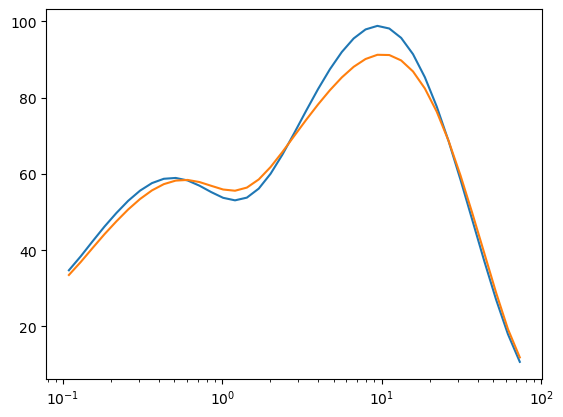

In [59]:
plt.semilogx(rp,rp*wgg[0])
plt.semilogx(rp,rp*wgg2[0])


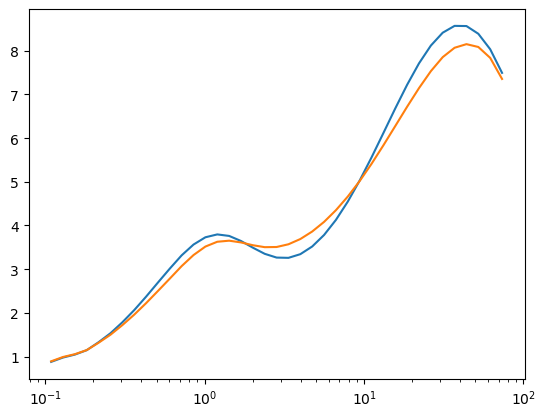

In [60]:
plt.semilogx(rp,rp*DeltaSigma_z[0])
plt.semilogx(rp,rp*DeltaSigma_z2[0])

#plt.semilogx(rp,rp*DeltaSigma_z2[0])

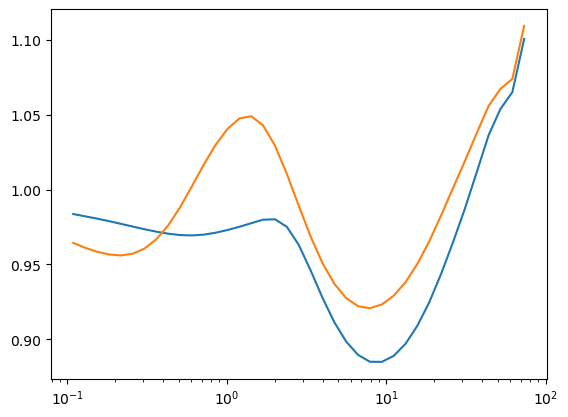

In [61]:
plt.semilogx(rp,wgg2[3]/wgg[3])
plt.semilogx(rp,wgg2[0]/wgg[0])

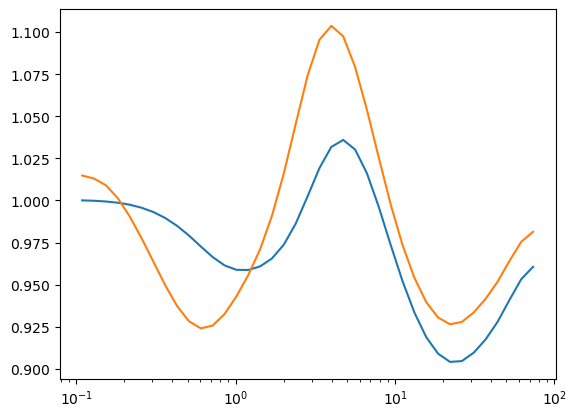

In [62]:
plt.semilogx(rp,DeltaSigma_z2[3]/DeltaSigma_z[3])
plt.semilogx(rp,DeltaSigma_z2[0]/DeltaSigma_z[0])


In [63]:
"""
Diagnostic tests for β^NL implementation
"""

import numpy as np
import matplotlib.pyplot as plt

def run_beta_nl_diagnostics(halo_model, iz=0, hod_params=None):
    """
    Comprehensive diagnostics for β^NL implementation.
    
    Parameters
    ----------
    halo_model : HaloModel instance with include_beta_nl=True
    iz : int, redshift index
    hod_params : dict, HOD parameters
    """
    if hod_params is not None:
        halo_model.set_hod_params(hod_params)
    
    z = halo_model.z_array[iz]
    print(f"=" * 60)
    print(f"β^NL Diagnostics at z = {z:.4f}")
    print(f"=" * 60)
    
    # ===========================================
    # Test 1: Check A(M_min) - mass fraction below M_min
    # ===========================================
    A_Mmin = halo_model.get_A_Mmin(iz)
    print(f"\n[Test 1] Mass normalization:")
    print(f"  A(M_min) = {A_Mmin:.6f}")
    print(f"  This is the mass fraction below M_min = 10^{halo_model.log10M_min:.1f}")
    if A_Mmin < 0:
        print(f"  ⚠️ WARNING: A(M_min) < 0 indicates mass function normalization issue!")
    elif A_Mmin > 0.5:
        print(f"  ⚠️ WARNING: A(M_min) > 0.5 seems too large - check M_min")
    else:
        print(f"  ✓ Looks reasonable")
    
    # ===========================================
    # Test 2: Check β^NL grid values
    # ===========================================
    if iz in halo_model._beta_nl_gl_cache:
        beta_gl = np.asarray(halo_model._beta_nl_gl_cache[iz])
        print(f"\n[Test 2] β^NL grid statistics:")
        print(f"  Shape: {beta_gl.shape}")
        print(f"  Range: [{beta_gl.min():.4f}, {beta_gl.max():.4f}]")
        print(f"  Mean: {beta_gl.mean():.4f}")
        print(f"  Fraction < -1: {(beta_gl < -1).mean()*100:.2f}%")
        print(f"  Fraction > 1: {(beta_gl > 1).mean()*100:.2f}%")
        print(f"  Fraction = 0: {(beta_gl == 0).mean()*100:.2f}%")
        
        if (beta_gl < -1).any():
            print(f"  ⚠️ WARNING: β^NL < -1 makes P_hh negative!")
        if (beta_gl == 0).mean() > 0.5:
            print(f"  ⚠️ WARNING: Many zeros - check k-range overlap")
    else:
        print(f"\n[Test 2] β^NL grid not cached for iz={iz}")
    
    # ===========================================
    # Test 3: Check β^NL at boundary masses
    # ===========================================
    if halo_model.beta_nl_interp is not None:
        interp = halo_model.beta_nl_interp
        k_test = np.array([0.1])  # Test at k = 0.1 h/Mpc
        
        print(f"\n[Test 3] β^NL at k=0.1 h/Mpc for different mass pairs:")
        mass_pairs = [
            (1e12, 1e12, "In emulator range"),
            (1e13, 1e13, "In emulator range"),
            (1e14, 1e14, "In emulator range"),
            (1e11, 1e11, "Below emulator"),
            (1e10, 1e10, "At M_min"),
            (1e15, 1e15, "At emulator edge"),
            (1e16, 1e16, "Above emulator"),
            (1e10, 1e14, "Mixed low/mid"),
        ]
        
        for M1, M2, desc in mass_pairs:
            try:
                beta_val = float(interp(k_test, M1, M2, z)[0])
                flag = ""
                if abs(beta_val) > 10:
                    flag = " ⚠️ LARGE"
                elif beta_val < -0.9:
                    flag = " ⚠️ NEAR -1"
                print(f"  β^NL(M1={M1:.0e}, M2={M2:.0e}) = {beta_val:+.4f} [{desc}]{flag}")
            except Exception as e:
                print(f"  β^NL(M1={M1:.0e}, M2={M2:.0e}) = ERROR: {e}")
    
    # ===========================================
    # Test 4: Check k-dependence
    # ===========================================
    if halo_model.beta_nl_interp is not None:
        print(f"\n[Test 4] β^NL k-dependence at M1=M2=10^13:")
        k_test = np.array([0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0])
        M_test = 1e13
        
        for k in k_test:
            try:
                beta_val = float(interp(np.array([k]), M_test, M_test, z)[0])
                print(f"  k={k:5.2f}: β^NL = {beta_val:+.4f}")
            except:
                print(f"  k={k:5.2f}: ERROR")
    
    # ===========================================
    # Test 5: Compare P_gg with and without β^NL
    # ===========================================
    print(f"\n[Test 5] Impact of β^NL on P_gg:")
    
    # Temporarily disable β^NL
    orig_include = halo_model.include_beta_nl
    orig_cache = halo_model._beta_nl_gl_cache.copy()
    
    halo_model.include_beta_nl = False
    P_gg_no_beta = halo_model.Pgg()[iz] if halo_model.n_z > 1 else halo_model.Pgg()
    
    halo_model.include_beta_nl = True
    halo_model._beta_nl_gl_cache = orig_cache
    P_gg_with_beta = halo_model.Pgg()[iz] if halo_model.n_z > 1 else halo_model.Pgg()
    
    k = halo_model.get_k()
    ratio = P_gg_with_beta / P_gg_no_beta
    
    # Find specific k values
    k_targets = [0.01, 0.1, 1.0]
    for kt in k_targets:
        idx = np.argmin(np.abs(k - kt))
        print(f"  k ≈ {k[idx]:.3f}: ratio = {ratio[idx]:.4f} ({(ratio[idx]-1)*100:+.1f}%)")
    
    print(f"  Overall ratio range: [{ratio.min():.4f}, {ratio.max():.4f}]")
    
    if ratio.min() < 0.5 or ratio.max() > 2.0:
        print(f"  ⚠️ WARNING: β^NL effect seems too strong!")
    
    # ===========================================
    # Test 6: Grid resolution sensitivity
    # ===========================================
    print(f"\n[Test 6] Checking interpolator grid parameters:")
    if halo_model.beta_nl_interp is not None:
        interp = halo_model.beta_nl_interp
        print(f"  n_k = {interp.n_k}")
        print(f"  n_mass = {interp.n_mass}")
        print(f"  k range: [{interp.k_min:.2e}, {interp.k_max:.2e}] h/Mpc")
        print(f"  M range: [10^{interp.log_M_min:.1f}, 10^{interp.log_M_max:.1f}] Msun/h")
        print(f"  Emulator valid: [10^{interp.log_M_emu_min:.1f}, 10^{interp.log_M_emu_max:.1f}]")
        
        # Check if HaloModel k-range matches
        k_hm = halo_model._k_array_internal / halo_model.h
        print(f"\n  HaloModel k range: [{k_hm.min():.2e}, {k_hm.max():.2e}] h/Mpc")
        
        if k_hm.min() < interp.k_min:
            print(f"  ⚠️ HaloModel k_min < interpolator k_min - zeros at low-k!")
        if k_hm.max() > interp.k_max:
            print(f"  ⚠️ HaloModel k_max > interpolator k_max - zeros at high-k!")
    
    return {
        'A_Mmin': A_Mmin,
        'P_gg_ratio': ratio,
        'k': k,
    }


def plot_beta_nl_diagnostics(halo_model, iz=0, figsize=(15, 10)):
    """
    Create diagnostic plots for β^NL.
    """
    if halo_model.beta_nl_interp is None:
        print("No β^NL interpolator available")
        return
    
    interp = halo_model.beta_nl_interp
    z = halo_model.z_array[iz]
    
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    
    # Plot 1: β^NL vs k for different masses
    ax = axes[0, 0]
    k_plot = np.geomspace(interp.k_min, interp.k_max, 100)
    masses = [1e11, 1e12, 1e13, 1e14, 1e15, 1e16]
    
    for M in masses:
        beta = np.array([float(interp(np.array([k]), M, M, z)[0]) for k in k_plot])
        ax.semilogx(k_plot, beta, label=f'M={M:.0e}')
    
    ax.axhline(0, color='k', ls='--', alpha=0.3)
    ax.axhline(-1, color='r', ls='--', alpha=0.3, label='β=-1 (P_hh=0)')
    ax.set_xlabel('k [h/Mpc]')
    ax.set_ylabel('β^NL')
    ax.set_title(f'β^NL(k) at z={z:.2f}, M1=M2')
    ax.legend(fontsize=8)
    ax.set_ylim(-2, 5)
    
    # Plot 2: β^NL vs mass at fixed k
    ax = axes[0, 1]
    M_plot = np.logspace(10, 16, 50)
    k_vals = [0.05, 0.1, 0.5, 1.0]
    
    for k in k_vals:
        beta = np.array([float(interp(np.array([k]), M, M, z)[0]) for M in M_plot])
        ax.semilogx(M_plot, beta, label=f'k={k}')
    
    ax.axhline(0, color='k', ls='--', alpha=0.3)
    ax.set_xlabel('M [Msun/h]')
    ax.set_ylabel('β^NL')
    ax.set_title(f'β^NL(M) at z={z:.2f}, M1=M2')
    ax.legend(fontsize=8)
    
    # Plot 3: 2D slice of β^NL grid
    ax = axes[0, 2]
    if iz in halo_model._beta_nl_gl_cache:
        beta_gl = np.asarray(halo_model._beta_nl_gl_cache[iz])
        k_idx = beta_gl.shape[0] // 2  # Middle k
        im = ax.imshow(beta_gl[k_idx], origin='lower', aspect='auto',
                       extent=[halo_model.log10M_min, halo_model.log10M_max,
                               halo_model.log10M_min, halo_model.log10M_max],
                       cmap='RdBu_r', vmin=-0.5, vmax=0.5)
        plt.colorbar(im, ax=ax, label='β^NL')
        ax.set_xlabel('log10(M1)')
        ax.set_ylabel('log10(M2)')
        ax.set_title(f'β^NL at k index {k_idx}')
    
    # Plot 4: P_gg ratio
    ax = axes[1, 0]
    orig_include = halo_model.include_beta_nl
    orig_cache = halo_model._beta_nl_gl_cache.copy()
    
    halo_model.include_beta_nl = False
    P_no = halo_model.Pgg()[iz] if halo_model.n_z > 1 else halo_model.Pgg()
    
    halo_model.include_beta_nl = True
    halo_model._beta_nl_gl_cache = orig_cache
    P_yes = halo_model.Pgg()[iz] if halo_model.n_z > 1 else halo_model.Pgg()
    
    k = halo_model.get_k()
    ax.semilogx(k, P_yes / P_no)
    ax.axhline(1, color='k', ls='--', alpha=0.3)
    ax.set_xlabel('k')
    ax.set_ylabel('P_gg(β^NL) / P_gg(no β^NL)')
    ax.set_title('Effect of β^NL on P_gg')
    
    # Plot 5: P_gm ratio
    ax = axes[1, 1]
    halo_model.include_beta_nl = False
    P_no = halo_model.Pgm()[iz] if halo_model.n_z > 1 else halo_model.Pgm()
    
    halo_model.include_beta_nl = True
    halo_model._beta_nl_gl_cache = orig_cache
    P_yes = halo_model.Pgm()[iz] if halo_model.n_z > 1 else halo_model.Pgm()
    
    ax.semilogx(k, P_yes / P_no)
    ax.axhline(1, color='k', ls='--', alpha=0.3)
    ax.set_xlabel('k')
    ax.set_ylabel('P_gm(β^NL) / P_gm(no β^NL)')
    ax.set_title('Effect of β^NL on P_gm')
    
    # Plot 6: Check Mmin boundary terms
    ax = axes[1, 2]
    if iz in halo_model._beta_nl_Mmin_row_cache:
        beta_Mmin = np.asarray(halo_model._beta_nl_Mmin_row_cache[iz])
        # Plot β^NL(M_min, M) vs k for a few M values
        M_indices = [0, len(halo_model.M_array)//4, len(halo_model.M_array)//2, -1]
        for mi in M_indices:
            ax.semilogx(k, beta_Mmin[:, mi], label=f'M={halo_model.M_array[mi]:.1e}')
        ax.axhline(0, color='k', ls='--', alpha=0.3)
        ax.set_xlabel('k')
        ax.set_ylabel('β^NL(M_min, M)')
        ax.set_title('Boundary term β^NL(M_min, M_j)')
        ax.legend(fontsize=8)
    
    plt.tight_layout()
    plt.savefig('beta_nl_diagnostics.png', dpi=150)
    plt.show()
    
    return fig


def test_resolution_convergence(cosmo_params, z, hod_params, 
                                 n_mass_values=[30, 50, 100, 200],
                                 n_k_values=[50, 100, 200]):
    """
    Test how results change with grid resolution.
    """
    from your_module import HaloModel  # Adjust import
    
    results = {}
    
    for n_m in n_mass_values:
        for n_k in n_k_values:
            key = f"nM{n_m}_nk{n_k}"
            print(f"Testing {key}...")
            
            beta_kwargs = {
                'n_k': n_k,
                'n_mass': n_m,
            }
            
            try:
                hm = HaloModel(
                    cosmo_params=cosmo_params,
                    z=z,
                    hod_type='standard',
                    include_beta_nl=True,
                    beta_nl_kwargs=beta_kwargs,
                    verbose=False,
                )
                hm.set_hod_params(hod_params)
                
                P_gg = hm.Pgg()
                P_gm = hm.Pgm()
                
                results[key] = {
                    'k': hm.get_k(),
                    'P_gg': P_gg,
                    'P_gm': P_gm,
                }
            except Exception as e:
                print(f"  Failed: {e}")
                results[key] = None
    
    # Plot convergence
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    ref_key = list(results.keys())[-1]  # Highest resolution as reference
    if results[ref_key] is not None:
        k_ref = results[ref_key]['k']
        P_gg_ref = results[ref_key]['P_gg']
        P_gm_ref = results[ref_key]['P_gm']
        
        for key, res in results.items():
            if res is not None and key != ref_key:
                axes[0].semilogx(k_ref, res['P_gg'] / P_gg_ref, label=key)
                axes[1].semilogx(k_ref, res['P_gm'] / P_gm_ref, label=key)
        
        axes[0].axhline(1, color='k', ls='--')
        axes[0].set_xlabel('k')
        axes[0].set_ylabel(f'P_gg / P_gg({ref_key})')
        axes[0].legend()
        
        axes[1].axhline(1, color='k', ls='--')
        axes[1].set_xlabel('k')
        axes[1].set_ylabel(f'P_gm / P_gm({ref_key})')
        axes[1].legend()
    
    plt.tight_layout()
    plt.savefig('resolution_convergence.png', dpi=150)
    plt.show()
    
    return results

In [64]:
10**12.6

3981071705534.969

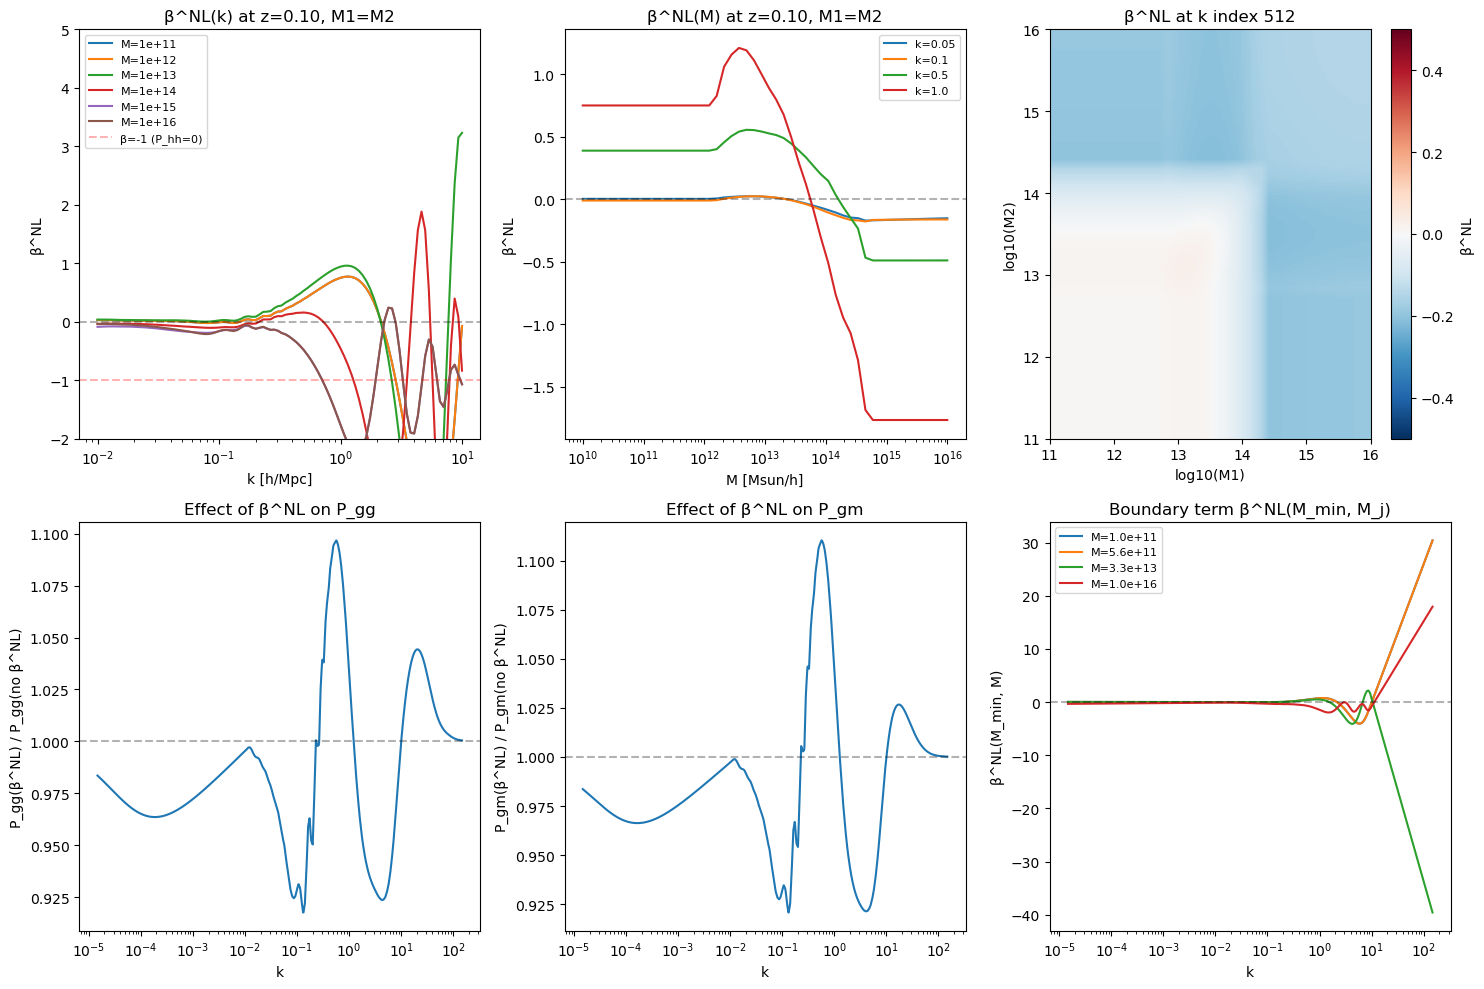

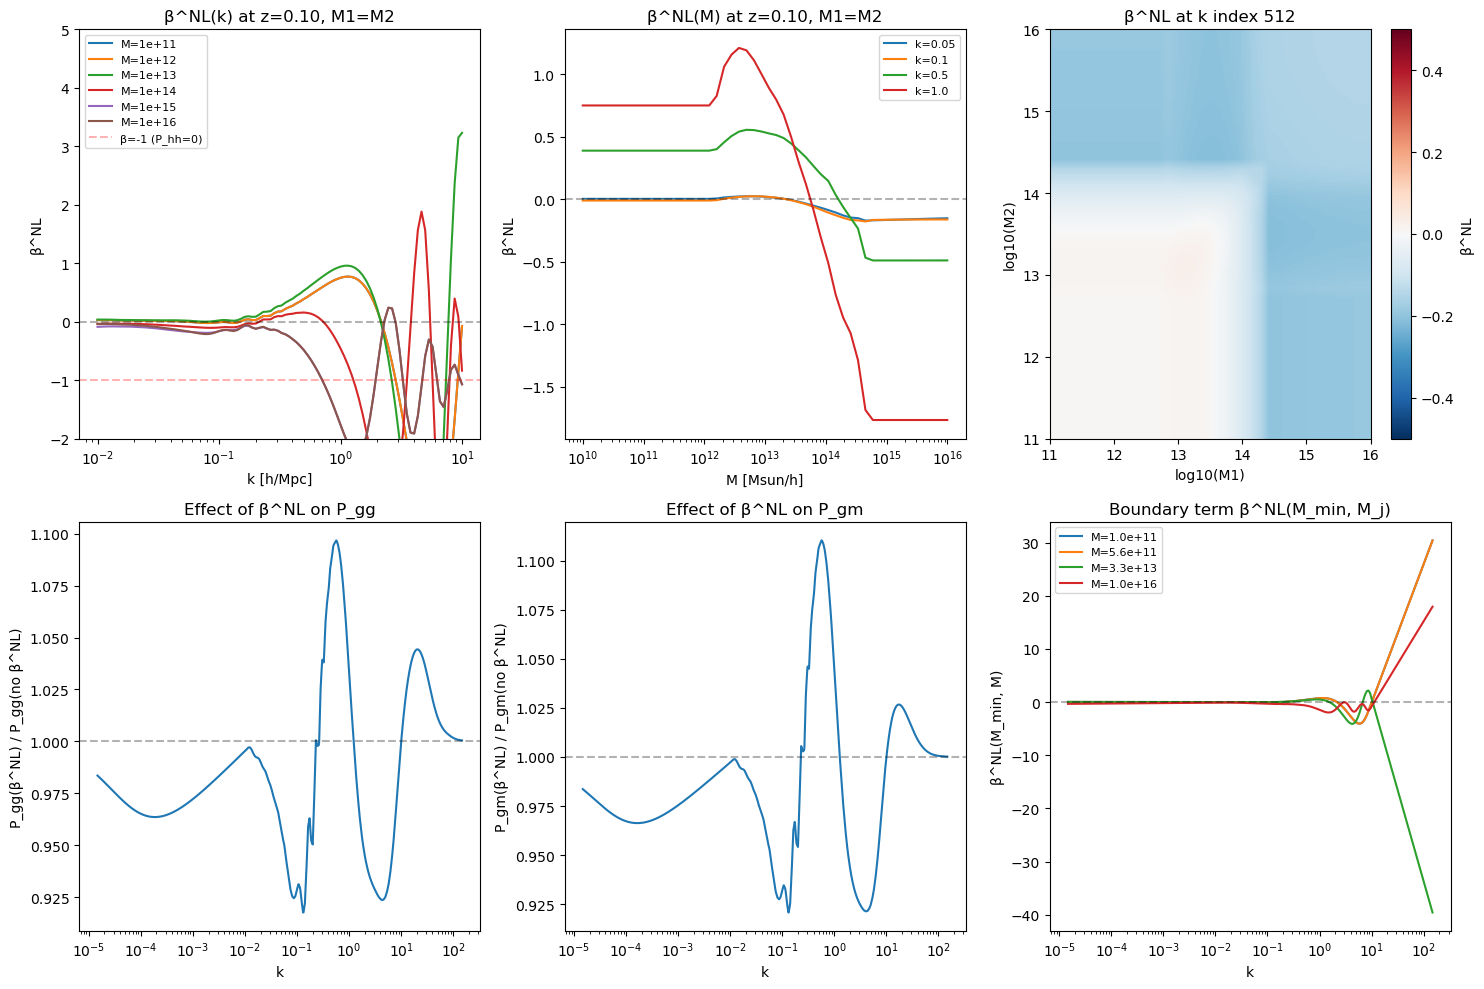

In [65]:
plot_beta_nl_diagnostics(hm,0)

In [ ]:
run_beta_nl_diagnostics(hm,0,csmf_params)

In [ ]:
plt.semilogx(rp,rp[:,None]*DeltaSigma_z.T)
plt.semilogx(rp,rp[:,None]*DeltaSigma_z2.T)

In [ ]:
plt.semilogx(rp,rp*wgg[0])
plt.semilogx(rp,rp*wgg2[0])

In [1]:
from HOD_NRV.HOD_analytical.halo_model import HaloModel

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [66]:
import numpy as np


z_array = np.array([0.1,0.2,0.25,0.3])
z_array = np.array([0.1,0.2,0.25,0.3])
#log_Mstar_bins = [(10.0, 10.3), (10.3, 10.6), (10.6, 10.9), (10.9, 11.2)]
M_array = np.array([9.5,9.8,10.5,10.9,11.2])
#M_array=np.array([5e9,1e10,5e10,1e11])
rp_bins = np.geomspace(0.1,80,40)
M_min = 10**M_array[:-1]
M_max = 10**M_array[1:]
rp = np.sqrt(rp_bins[:-1]*rp_bins[1:])


dict_cosmo = {
    'h': 0.6766,
    'Omc': 0.11933 / 0.6766**2,
    'Omb': 0.02242 / 0.6766**2,
    'A_s': 2.105e-09,
    'n_s': 0.9665,
    'Omnu': 0.0014034
}

# Just cosmology


# Just cosmology
# CSMF HOD parameters
csmf_params = {
    'M0': 10.519,         # log10(M*) [Msun/h²]
    'M1': 11.138,         # log10(Mh) [Msun/h]
    'gamma1': 7.0,
    'gamma2': 0.2,
    'sigma_c': 0.1,
    'alpha_s': -0.85,
    'b0': -0.024,
    'b1': 1.1
}

# Halo model
hm = HaloModel(dict_cosmo,  hod_type='csmf',
               mass_function='Tinker10', halo_bias='Tinker10',
                z=z_array,mass_definition='MassDef200c',
                k_array=np.geomspace(1e-5, 100, 1024),  # Always in natural units (1/Mpc)
                M_min=1e11,
                M_max=1e16,
                units_per_h=True,
                Mstar_min=M_min,
                Mstar_max=M_max)

rp, DeltaSigma_z = hm.DeltaSigma(rp,
   # method='direct',
    rp_bins=rp_bins,
    hod_params=csmf_params)


rp, wgg = hm.wgg(rp,
    #method='direct',
    rp_bins=rp_bins,
    hod_params=csmf_params)


Cosmology: h=0.6766, Ωc=0.2607, Ωb=0.0490
  Halo: Tinker10, Tinker10
  Dark emulator: enabled
HaloModel: 4 z, 1024 k, 200 M points
  HOD: csmf, f_c=1.0, f_s=1.0
  Mass: [10^11.0, 10^16.0]
  β^NL: disabled


In [13]:

dict_cosmo = {
    'h': 0.6766,
    'Omc': 0.11933 / 0.6766**2,
    'Omb': 0.02242 / 0.6766**2,
    'A_s': 2.105e-09,
    'n_s': 0.9665,
    'Omnu': 0.0014034
}

In [15]:
dict_cosmo

{'h': 0.681,
 'Omc': 0.25601,
 'Omb': 0.0486,
 'A_s': 2.099e-09,
 'n_s': 0.967,
 'Omnu': 0.00139}

In [200]:
# Halo model

dict_cosmo = {
        'h': 0.681,
        'Omc': 0.306-0.0486-1.39e-3,
        'Omb': 0.0486,
        'A_s': 2.099e-9,
        'n_s': 0.967,
        'Omnu':1.39e-3
    }


beta_nl_opts = {
    'n_k': 100,
    'n_mass': 30,
    'k_min': 1e-2,
    'k_max': 10.0,
    'log_M_min': 12.6,
    'log_M_max': 15.0,
    'method': 'linear',
    'verbose': True,
}


hm = HaloModel(dict_cosmo,  hod_type='ELG_GHOD',
               mass_function='Tinker10', halo_bias='Tinker10',
                z=1.0,mass_definition='MassDef200m',
                k_array=np.geomspace(1e-5, 100, 1024),  # Always in natural units (1/Mpc)
                M_min=1e9,
                M_max=1e16,
                units_per_h=True,
                Mstar_min=M_min,
                Mstar_max=M_max,include_beta_nl=False,beta_nl_kwargs=beta_nl_opts)


Cosmology: h=0.6810, Ωc=0.2560, Ωb=0.0486
  Halo: Tinker10, Tinker10
  Dark emulator: enabled
HaloModel: 1 z, 1024 k, 200 M points
  HOD: elg_ghod, f_c=1.0, f_s=1.0
  Mass: [10^9.0, 10^16.0]
  β^NL: disabled


In [201]:
Ac = 0.1
Mmin = 12.3 - np.log10(dict_cosmo['h'])
sig_M = 0.4
M1 = 13 - np.log10(dict_cosmo['h'])
As = 0.1
alpha = 0.6
kappa = 0.8
dict_params = {'kappa':kappa,'Ac':Ac,'As':As,'log10Mmin':Mmin, 'sig_M':sig_M,'log10M1':M1,'alpha':alpha}


In [202]:
Mmin

np.float64(12.466852888087216)

In [203]:
rpbins = np.geomspace(5e-2,80,16)
pibins = np.linspace(-100,100,21)
mubins = np.linspace(-1,1,201)
sbins = np.linspace(0,150,31)
bins_comp = np.geomspace(5e-2,100,31)

rp_centers = (rpbins[1:] + rpbins[:-1])/2.
rp_centers2 =  np.sqrt(rpbins[:-1] * rpbins[1:])
rp_centers3 = 10 ** ((np.log10(rpbins[:-1]) + np.log10(rpbins[1:])) / 2)

In [204]:
rp_centers2.shape

(15,)

In [205]:
rp,dsigma = hm.DeltaSigma(rp_centers2,rp_bins=rpbins,hod_params=dict_params)

In [206]:
dsigma

array([15.08880495, 10.93901933,  7.32664359,  4.6545301 ,  2.61178488,
        1.38055996,  0.73976987,  0.44844646,  0.33972334,  0.2982912 ,
        0.26774129,  0.22715229,  0.17420558,  0.11703475,  0.06678171])

In [207]:
rpT,dsigmaT = np.loadtxt('/Users/ler13nrv/Documents/NRV_HOD/result_dsigma_numerical').T

In [208]:
import matplotlib.pyplot as plt

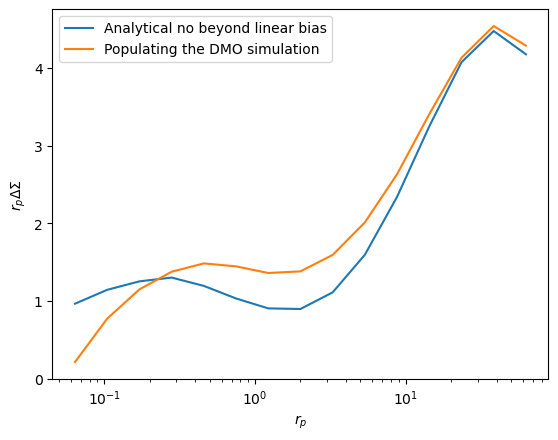

In [209]:
plt.semilogx(rpT,dsigma*rpT,label="Analytical no beyond linear bias")
plt.semilogx(rpT,dsigmaT*rpT,label="Populating the DMO simulation")
plt.xlabel(r'$r_p$')
plt.ylabel(r'$r_p \Delta \Sigma$')
plt.legend(loc=0,fontsize=10)
plt.savefig('deltasigma_prediction.png',bbox_inches='tight')

In [45]:
import numpy as np

# Test at a few masses
test_masses = [3e12, 5e12, 1e13, 1e14,1e15]
k_test = np.array([0.5])  # Single k for clarity
z = 0.0

print("M [Msun/h] | b(M) | P_hh(k=0.1) | P_hh / b²")
print("-" * 50)

for M in test_masses:
    b = hm.emu.get_bias_mass(M, z)[0][0]
    Phh = hm.emu.get_phh_mass(k_test, M, M, z)[0]
    Pk_lin = hm.linear_power(k_test,z)# your linear power at k=0.1
    print(f"{M:.1e} | {b:.3f} | {Phh:.3e} | {Phh/b**2:.3e}")

M [Msun/h] | b(M) | P_hh(k=0.1) | P_hh / b²
--------------------------------------------------
3.0e+12 | 0.857 | 3.407e+02 | 4.641e+02
5.0e+12 | 0.930 | 4.148e+02 | 4.794e+02
1.0e+13 | 1.064 | 5.358e+02 | 4.736e+02
1.0e+14 | 2.061 | 1.538e+03 | 3.622e+02
1.0e+15 | 5.829 | 4.910e+03 | 1.445e+02


In [34]:
hm.emu 